# WCTE - Ni-Cf source calibration
# FromKaMing_forClaudeReco_noCuts Data

## Tareas para 17/04/2026

- Aplicar los cortes q hice por separado pero todo junto ahora (el corte d la carga no hace falta) a los datos nuevos de diego!!

- Hacer la resta bin a bin bien (para que sig no esté desplazada); esto pensarlo bien de bien

- En la distribución tRMS investigar la colina después del pico. Aquí hacer varios histogramas (como 20 o 50) así: antes un histograma de nº de hits en cada evento, ahora cogemos un evento y hacemos el hist de tRMS de cada hit en su evento. Vemos si hay algún patrón de hits en el mismo evento. Diego y JA sospechan que es por carga que salta sistemáticamente en la electrónica del PMT.

- Ahora esto tengo que pensarlo bn: tengo que calcular el vértice de reconstrucción $\vec{x}$ usando los tiempos. Tengo que buscar la posición $x$ que hace que los tiempos medidos y los predichos coincidan lo mejor posible. Osea, distintas posiciones del evento hasta encintrar la que mejor explica los tiempos observados. Tengo que minimizar esta cantidad, por mínimos cuadrados quizás? Básicamente tengo que hacer un fit

In [1]:
import sys
import os
import uproot

# Añade el directorio padre al sys.path
sys.path.append(os.path.abspath("/mnt/netapp2/Store_uni/home/usc/ie/dcr/software/hk"))

import hipy.hipy.pltext  as pltext
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from tqdm import tqdm

pltext.style()

## Datos

In [2]:
datapath = "/home/usc/ie/tam/nicf_first_semester/NiCf_analysis/teresa_analysis/"    #ahora los csv están en mi carpeta
filename_bkg = "df_bkgFromKaMing_forClaudeReco_noCuts.csv" 
data_bkg     = pd.read_csv(datapath+filename_bkg)

filename_sig = "df_sigFromKaMing_forClaudeReco_noCuts.csv"
data_sig     = pd.read_csv(datapath+filename_sig)


In [3]:
data_bkg

,Unnamed: 0,event_id,candidate_id,hit_pmt_calibrated_times,hit_pmt_charges,hit_mpmt_slot_ids,hit_pmt_position_ids,pmt_id
0,0,0,0,209221.084343,103.0,19,12,373
1,1,0,0,209223.152791,119.0,19,4,365
2,2,0,0,209233.144440,175.0,19,10,371
3,3,0,1,209588.321986,97.0,100,0,1900
4,4,0,1,209590.743413,104.0,101,13,1932
...,...,...,...,...,...,...,...,...
18253236,18253236,83110,645853,247287.565400,180.0,3,18,75
18253237,18253237,83110,645854,331560.611688,141.0,8,1,153
18253238,18253238,83110,645854,331562.449078,97.0,2,1,39
18253239,18253239,83110,645854,331566.346411,132.0,52,10,998


In [4]:
data_sig

,Unnamed: 0,event_id,candidate_id,hit_pmt_calibrated_times,hit_pmt_charges,hit_mpmt_slot_ids,hit_pmt_position_ids,pmt_id
0,0,0,0,63479.663380,83.0,1,5,24
1,1,0,0,63480.392541,133.0,46,12,886
2,2,0,0,63496.106182,180.0,8,5,157
3,3,0,1,65913.196181,75.0,69,17,1328
4,4,0,1,65913.202297,137.0,70,1,1331
...,...,...,...,...,...,...,...,...
30143260,30143260,83111,1955360,494925.804957,111.0,88,9,1681
30143261,30143261,83111,1955360,494926.207864,215.0,90,16,1726
30143262,30143262,83111,1955360,494926.448105,161.0,88,8,1680
30143263,30143263,83111,1955360,494926.550472,61.0,89,17,1708


El proceso es el siguiente:

$^{252}\text{Cf}\rightarrow ^{148}\text{Ba}+^{106}\text{Mo}+4n$

$^{58}\text{Ni}+n\rightarrow ^{59}\text{Ni}+\gamma$

Los fotones son los que se detectan, vemos que en este run detectamos 18253241 fotones (hits) de background y 30143265 hits de sig+bkg. Para organizar esta gigantesca información definimos los "eventos", que corresponden a la toma de datos en un intervalo de tiempo de 500 [$\mu$s], cada uno con un número variable de fotones que llegan al WCTE. Indexamos los eventos con el event_id.

En estos eventos hay candidates (fotones registrados que creemos que provienen del decay del $^{58}\text{Ni}$), y debemos separar el "ruido" de los candidates.

ATENCIÓN! Ahora estamos usando un algoritmo llamado *Greedy nthits*, i.e., usamos una **sliding window** que es la que define el tamaño del candidate (el candidate es lo que podría corresponder a lo que buscamos). Nosotros tenemos una readout window de 500 [$\mu$s], que es lo que define el tamaño del evento. Dentro de esta readout window es donde está la sliding window, configurada a 20 [ns]. La condición inicial de esta siliding window es que el número mínimo de hits que tenga dentro sea 3. Si llegan 3 o más hits a esta sliding window, se desplaza al final del primer "cachito" de candidate. Ahora la condición es que al menos llegue un hit en la sliding window desplazada. Si llega uno o más hits a esta sliding window desplazada, cuando termina se vuelve a desplazar. Así va sumando cachitos de las sliding window, y para cuando no llega ningún hit en la sliding window. La suma de estos cachitos es el tamaño del candidate.


Como me interesan los candidates agrupo los hits en su candidate correspondiente con .groupby(). Sumo hit_pmt_charges (carga total en cada candidate), cuento cuántos hits tiene cada candidate (cuántos fotones tiene cada candidate), y la RMS del tiempo (si trms es pequeña los hits han llegado casi al mismo tiempo al PMT en este candidate).

In [5]:
data_by_candidate_bkg=data_bkg.groupby("candidate_id")

total_charge_by_candidate_bkg = data_by_candidate_bkg["hit_pmt_charges"].sum() #data_by_candidate["hit_pmt_charges"] con los [] seleccionamos
total_nhits_by_candidate_bkg = data_by_candidate_bkg.size() #.size() devuelve el nº de elementos, osea el nº de hits en cada candidate
total_trms_by_candidate_bkg  = data_by_candidate_bkg["hit_pmt_calibrated_times"].std() #.std() ya lo calcula q facil, pero por q se le llama total_trms?? No hay solo una?

print(f"Tenemos {len(data_by_candidate_bkg)} candidates (grupos de hits) de bkg") #este será nuestro eje x en los scatters

data_by_candidate_sig=data_sig.groupby("candidate_id")
total_charge_by_candidate_sig=data_by_candidate_sig["hit_pmt_charges"].sum()
total_nhits_by_candidate_sig = data_by_candidate_sig.size()
total_trms_by_candidate_sig  = data_by_candidate_sig["hit_pmt_calibrated_times"].std()

print(f"Tenemos {len(data_by_candidate_sig)} candidates (grupos de hits) de sig+bkg") #este será nuestro eje x en los scatters

Tenemos 645855 candidates (grupos de hits) de bkg
Tenemos 1955361 candidates (grupos de hits) de sig+bkg


## Muestras contaminadas

Hemos almacenado la carga total por candidate, el nº de hits por candidate y la trms por candidate en series: total_charge_by_candidate_bkg, total_nhits_by_candidate_bkg, total_trms_by_candidate_bkg (igual para los datos de señal). Ahora hacemos un gráfico de dispersión (scatter plot, no une los puntos) de cada serie frente el índice que indexa cada candidate.

plt.scatter(x.index, y.values) ; .index indexa los elementos de la serie y coge los índices, .values da los valores

Text(0.5, 0.92, 'Muestras iniciales (contaminadas). Con 645855 candidates de bkg y 1955361 candidates de sig+bkg')

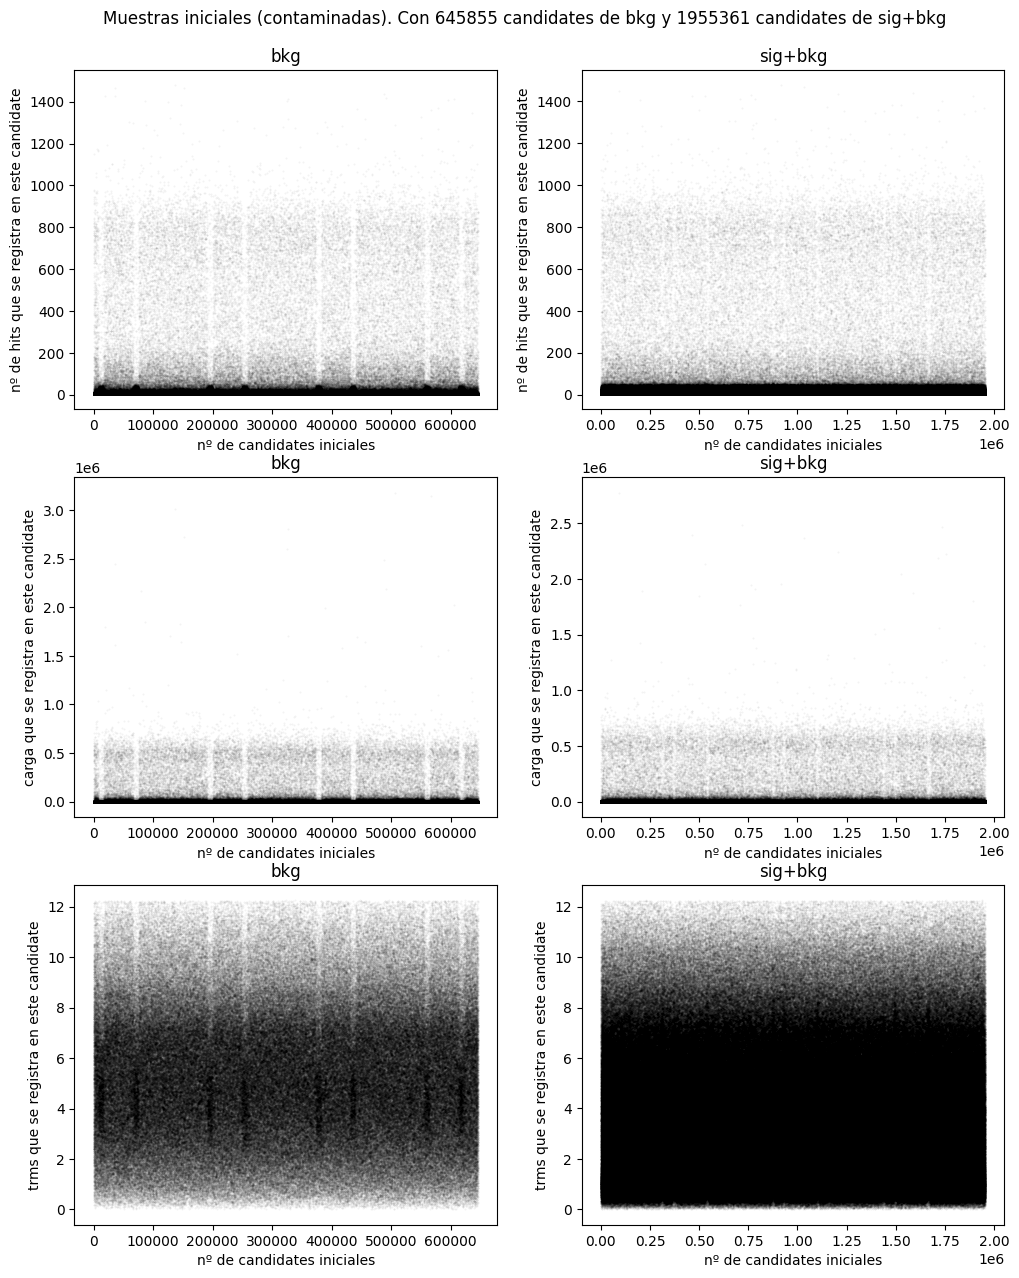

In [6]:
subplot = pltext.canvas(6)

subplot(1)
plt.scatter(total_nhits_by_candidate_bkg.index, total_nhits_by_candidate_bkg.values, s=0.2, alpha=0.05)
plt.xlabel("nº de candidates iniciales")
plt.ylabel("nº de hits que se registra en este candidate")
plt.title("bkg")

subplot(2)
plt.scatter(total_nhits_by_candidate_sig.index, total_nhits_by_candidate_sig.values, s=0.2, alpha=0.05)
plt.xlabel("nº de candidates iniciales")
plt.ylabel("nº de hits que se registra en este candidate")
plt.title("sig+bkg")

subplot(3)
plt.scatter(total_charge_by_candidate_bkg.index, total_charge_by_candidate_bkg.values, s=0.2, alpha=0.05)
plt.xlabel("nº de candidates iniciales")
plt.ylabel("carga que se registra en este candidate")
plt.title("bkg")

subplot(4)
plt.scatter(total_charge_by_candidate_sig.index, total_charge_by_candidate_sig.values, s=0.2, alpha=0.05)
plt.xlabel("nº de candidates iniciales")
plt.ylabel("carga que se registra en este candidate")
plt.title("sig+bkg")

subplot(5)
plt.scatter(total_trms_by_candidate_bkg.index, total_trms_by_candidate_bkg.values, s=0.2, alpha=0.05)
plt.xlabel("nº de candidates iniciales")
plt.ylabel("trms que se registra en este candidate")
plt.title("bkg")

subplot(6)
plt.scatter(total_trms_by_candidate_sig.index, total_trms_by_candidate_sig.values, s=0.2, alpha=0.05)
plt.xlabel("nº de candidates iniciales")
plt.ylabel("trms que se registra en este candidate")
plt.title("sig+bkg")

plt.suptitle(f"Muestras iniciales (contaminadas). Con {len(data_by_candidate_bkg)} candidates de bkg y {len(data_by_candidate_sig)} candidates de sig+bkg", y=0.92)

#plt.savefig(f"{output_directory}/Muestras_contaminadas.png", dpi=500, bbox_inches="tight")

## Muestras de candidates descontaminadas

Utilizaremos el scatter "nº total de hits de cada candidate vs nº de candidate" para eliminar los candidates que no nos interesan y quedarnos con los candidates buenos. Hago de nuevo este scatter:

Text(0.5, 0.98, 'nº total de hits de cada candidate vs nº de candidate')

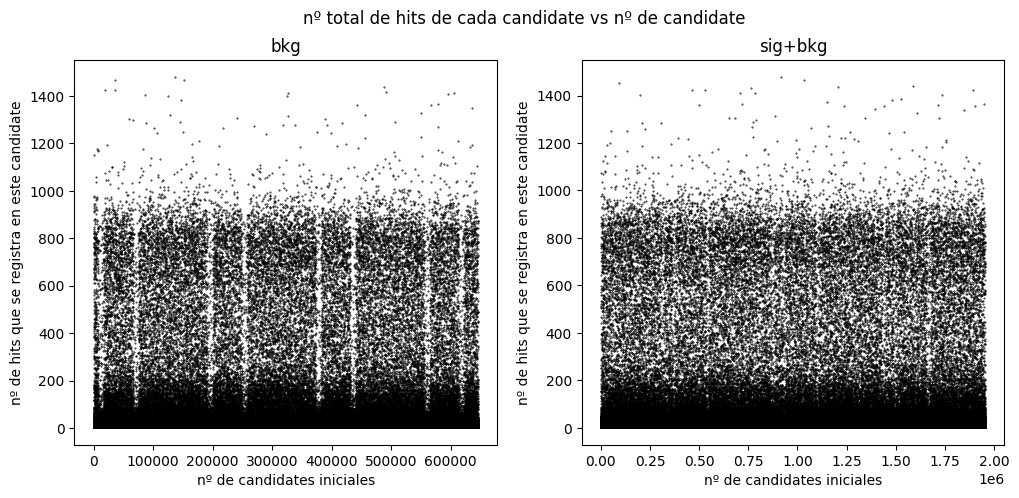

In [293]:
subplot = pltext.canvas(2)

subplot(1)
plt.scatter(total_nhits_by_candidate_bkg.index, total_nhits_by_candidate_bkg.values, s=0.2, alpha=0.9)
plt.xlabel("nº de candidates iniciales")
plt.ylabel("nº de hits que se registra en este candidate")
plt.title("bkg")

subplot(2)
plt.scatter(total_nhits_by_candidate_sig.index, total_nhits_by_candidate_sig.values, s=0.2, alpha=0.9)
plt.xlabel("nº de candidates iniciales")
plt.ylabel("nº de hits que se registra en este candidate")
plt.title("sig+bkg")

plt.suptitle("nº total de hits de cada candidate vs nº de candidate")

Vemos que es evidente que los spills tienen una periodicidad, esto podría inspeccionarlo más a fondo pero de momento voy solo a quitarlos (JA me dijo que es por cómo el algoritmo nuevo recopila los datos). Aquí no hay valores saturantes. Además, en bkg se miden muchos eventos que registran entre 500-1000 hits, esto tiene que ser ruido de una fuente externa porque es imposible que sea señal.

Que se hayan quitado los spills es por algo que hizo Diego. Como el código se vuelve loco si intento quitar candidates de lo que eran los spills mejor los dejo como están.

In [8]:
#quiero quitar los spills y los que saturan
#lo lógico primero es bucar cuál es el valor exacto de saturación:

max_value_of_total_nhits_by_candidate_bkg = total_nhits_by_candidate_bkg.max()  #aquí .max() va con () porque realiza un cálculo
min_value_of_total_nhits_by_candidate_bkg = total_nhits_by_candidate_bkg.min()  #aquí .min() va con () porque realiza un cálculo

print(f"{max_value_of_total_nhits_by_candidate_bkg} es el valor máximo de nº de hits en los candidates para bkg")
print(f"{min_value_of_total_nhits_by_candidate_bkg} es el valor mínimo de nº de hits en los candidates para bkg")

#vemos con el valor máximo y cambiando el alpha que no hay valores saturantes

#igual para signal
max_value_of_total_nhits_by_candidate_sig = total_nhits_by_candidate_sig.max()
min_value_of_total_nhits_by_candidate_sig = total_nhits_by_candidate_sig.min()

print(f"{max_value_of_total_nhits_by_candidate_sig} es el valor máximo de nº de hits en los candidates para sig+bkg")
print(f"{min_value_of_total_nhits_by_candidate_sig} es el valor mínimo de nº de hits en los candidates para sig+bkg")

1479 es el valor máximo de nº de hits en los candidates para bkg
3 es el valor mínimo de nº de hits en los candidates para bkg
1477 es el valor máximo de nº de hits en los candidates para sig+bkg
3 es el valor mínimo de nº de hits en los candidates para sig+bkg


### Quitar spills bkg

(545000.0, 635000.0)

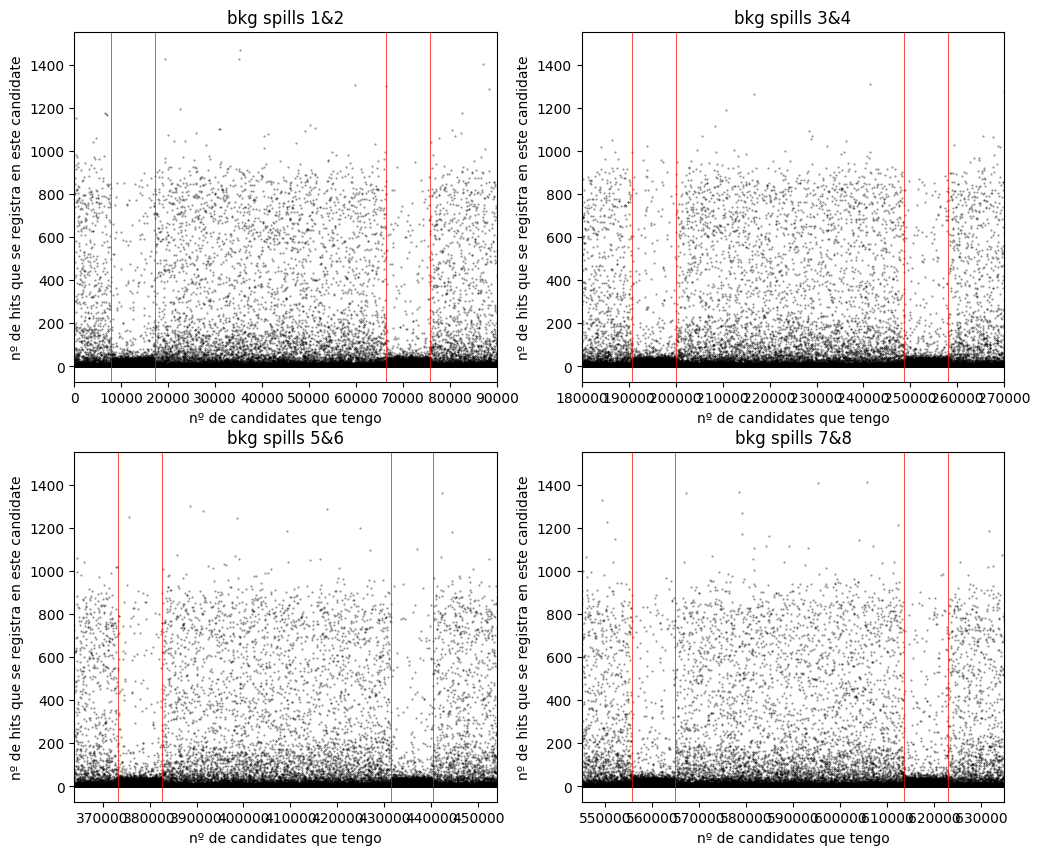

In [253]:
#vale ahora tengo que quitar los dos spills

subplot = pltext.canvas(4)

subplot(1)
plt.scatter(total_nhits_by_candidate_bkg.index, total_nhits_by_candidate_bkg.values, s=0.2, alpha=0.5)
plt.xlabel("nº de candidates que tengo")
plt.ylabel("nº de hits que se registra en este candidate")
plt.title("bkg spills 1&2")

x_lines_spill1_bkg = [7750, 17100]     #dibujo los límites (a ojo, seguro que hay otra forma más eficiente de hacerlo)
x_lines_spill2_bkg = [66400, 75750]      #configuro el intervalo igual para los dos: 9350
for x in x_lines_spill1_bkg:
    plt.axvline(x=x, color="r", linestyle="-", linewidth=0.5) 
for x in x_lines_spill2_bkg:
    plt.axvline(x=x, color="r", linestyle="-", linewidth=0.5)

plt.xlim(0, 90000) #configuro para ver el mismo intervalo siempre en el eje x: 90000

subplot(2)
plt.scatter(total_nhits_by_candidate_bkg.index, total_nhits_by_candidate_bkg.values, s=0.2, alpha=0.5)
plt.xlabel("nº de candidates que tengo")
plt.ylabel("nº de hits que se registra en este candidate")
plt.title("bkg spills 3&4")

x_lines_spill3_bkg = [190800, 200150]   #dibujo los límites (a ojo, seguro que hay otra forma más eficiente de hacerlo)
x_lines_spill4_bkg = [248700, 258050]
for x in x_lines_spill3_bkg:
    plt.axvline(x=x, color="r", linestyle="-", linewidth=0.5) 
for x in x_lines_spill4_bkg:
    plt.axvline(x=x, color="r", linestyle="-", linewidth=0.5) 

plt.xlim(180000, 270000)

subplot(3)
plt.scatter(total_nhits_by_candidate_bkg.index, total_nhits_by_candidate_bkg.values, s=0.2, alpha=0.5)
plt.xlabel("nº de candidates que tengo")
plt.ylabel("nº de hits que se registra en este candidate")
plt.title("bkg spills 5&6")

x_lines_spill5_bkg = [373270, 382620]   #dibujo los límites (a ojo, seguro que hay otra forma más eficiente de hacerlo)
x_lines_spill6_bkg = [431400, 440250]
for x in x_lines_spill5_bkg:
    plt.axvline(x=x, color="r", linestyle="-", linewidth=0.5) 
for x in x_lines_spill6_bkg:
    plt.axvline(x=x, color="r", linestyle="-", linewidth=0.5) 

plt.xlim(364000, 454000)

subplot(4)
plt.scatter(total_nhits_by_candidate_bkg.index, total_nhits_by_candidate_bkg.values, s=0.2, alpha=0.5)
plt.xlabel("nº de candidates que tengo")
plt.ylabel("nº de hits que se registra en este candidate")
plt.title("bkg spills 7&8")

x_lines_spill7_bkg = [555700, 564850]   #dibujo los límites (a ojo, seguro que hay otra forma más eficiente de hacerlo)
x_lines_spill8_bkg = [613700, 623050]
for x in x_lines_spill7_bkg:
    plt.axvline(x=x, color="r", linestyle="-", linewidth=0.5) 
for x in x_lines_spill8_bkg:
    plt.axvline(x=x, color="r", linestyle="-", linewidth=0.5) 

plt.xlim(545000, 635000)


### Quitar spills sig+bkg

Text(0.5, 1.0, 'sig+bkg')

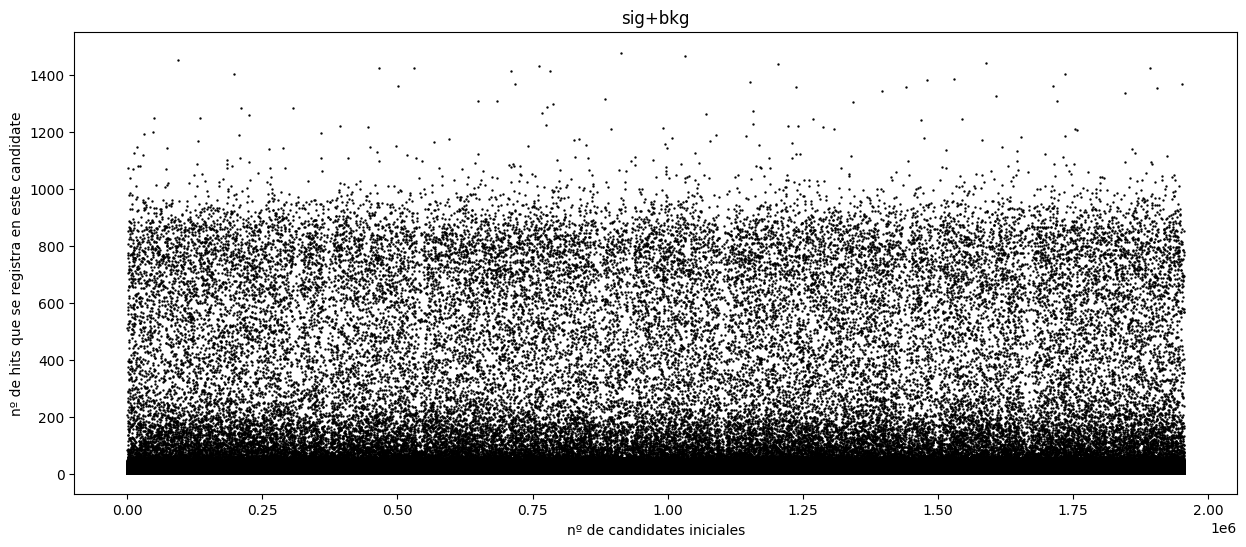

In [229]:
plt.figure(figsize=(15,6))
plt.scatter(total_nhits_by_candidate_sig.index, total_nhits_by_candidate_sig.values, s=0.5, alpha=1)
plt.xlabel("nº de candidates iniciales")
plt.ylabel("nº de hits que se registra en este candidate")
plt.title("sig+bkg")

(200000.0, 750000.0)

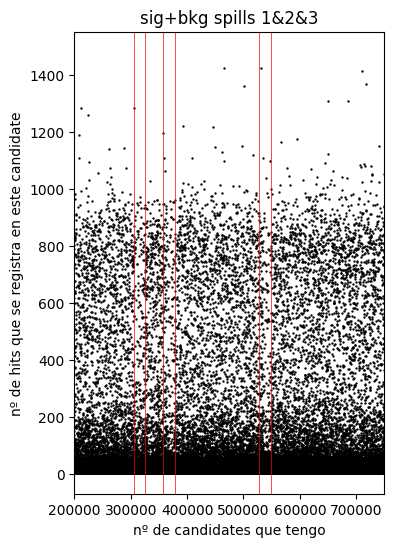

In [252]:
plt.figure(figsize=(4,6))
plt.scatter(total_nhits_by_candidate_sig.index, total_nhits_by_candidate_sig.values, s=0.5, alpha=1)
plt.xlabel("nº de candidates que tengo")
plt.ylabel("nº de hits que se registra en este candidate")
plt.title("sig+bkg spills 1&2&3")

x_lines_spill1_sig = [305000, 325000]     #dibujo los límites (a ojo, seguro que hay otra forma más eficiente de hacerlo)
x_lines_spill2_sig = [358000, 378000]      #configuro el intervalo igual para los dos: 430
x_lines_spill3_sig = [528000, 548000]
for x in x_lines_spill1_sig:
    plt.axvline(x=x, color="r", linestyle="-", linewidth=0.5) 
for x in x_lines_spill2_sig:
    plt.axvline(x=x, color="r", linestyle="-", linewidth=0.5)
for x in x_lines_spill3_sig:
    plt.axvline(x=x, color="r", linestyle="-", linewidth=0.5)

plt.xlim(0.2e6, 0.75e6)

(750000.0, 1300000.0)

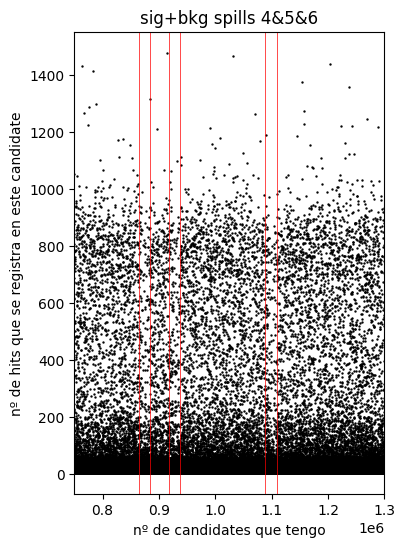

In [276]:
plt.figure(figsize=(4,6))
plt.scatter(total_nhits_by_candidate_sig.index, total_nhits_by_candidate_sig.values, s=0.5, alpha=1)
plt.xlabel("nº de candidates que tengo")
plt.ylabel("nº de hits que se registra en este candidate")
plt.title("sig+bkg spills 4&5&6")

x_lines_spill4_sig = [865000, 885000]     #dibujo los límites (a ojo, seguro que hay otra forma más eficiente de hacerlo)
x_lines_spill5_sig = [917000, 937000]      #configuro el intervalo igual para los dos: 430
x_lines_spill6_sig = [1089000, 1109000]
for x in x_lines_spill4_sig:
    plt.axvline(x=x, color="r", linestyle="-", linewidth=0.5) 
for x in x_lines_spill5_sig:
    plt.axvline(x=x, color="r", linestyle="-", linewidth=0.5)
for x in x_lines_spill6_sig:
    plt.axvline(x=x, color="r", linestyle="-", linewidth=0.5)

plt.xlim(0.75e6, 1.3e6)

(1300000.0, 1850000.0)

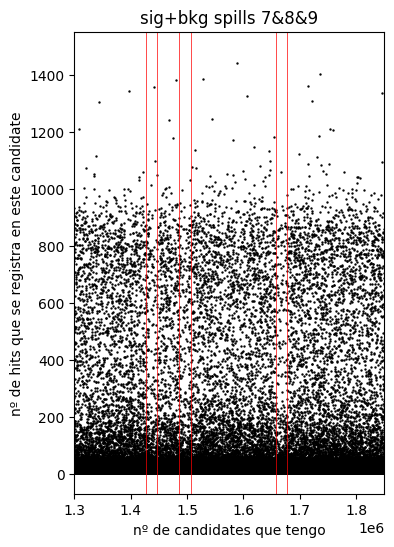

In [289]:
plt.figure(figsize=(4,6))
plt.scatter(total_nhits_by_candidate_sig.index, total_nhits_by_candidate_sig.values, s=0.5, alpha=1)
plt.xlabel("nº de candidates que tengo")
plt.ylabel("nº de hits que se registra en este candidate")
plt.title("sig+bkg spills 7&8&9")

x_lines_spill7_sig = [1427000, 1447000]     #dibujo los límites (a ojo, seguro que hay otra forma más eficiente de hacerlo)
x_lines_spill8_sig = [1486000, 1506000]      #configuro el intervalo igual para los dos: 430
x_lines_spill9_sig = [1657000, 1677000]
for x in x_lines_spill7_sig:
    plt.axvline(x=x, color="r", linestyle="-", linewidth=0.5) 
for x in x_lines_spill8_sig:
    plt.axvline(x=x, color="r", linestyle="-", linewidth=0.5)
for x in x_lines_spill9_sig:
    plt.axvline(x=x, color="r", linestyle="-", linewidth=0.5)

plt.xlim(1.30E+06, 1.85E+06)

(1300000.0, 1850000.0)

<Figure size 1200x1000 with 0 Axes>

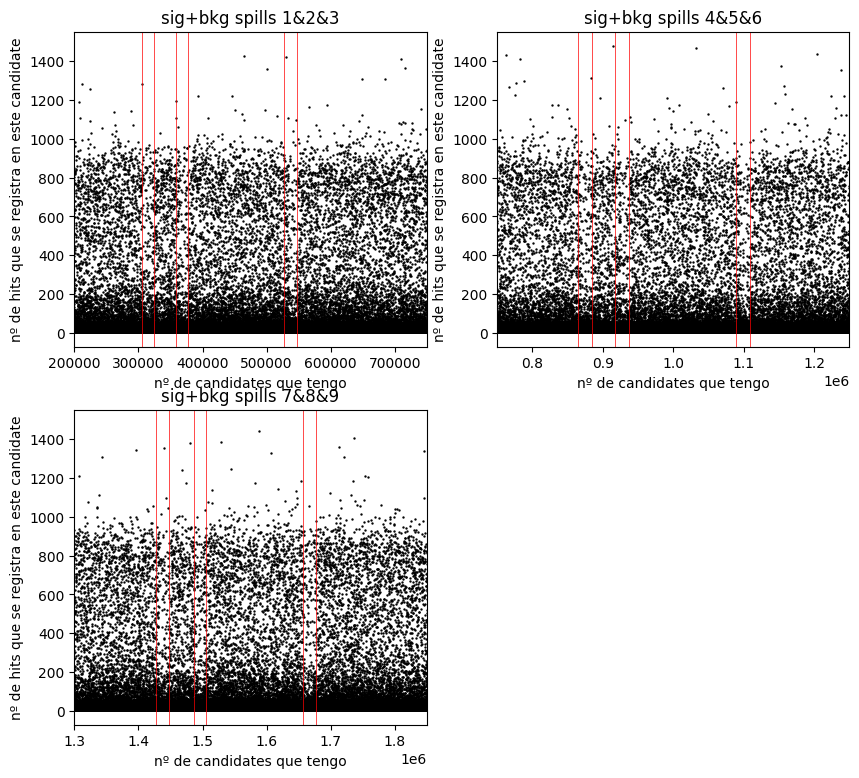

In [300]:
#vale ahora tengo que quitar los dos spills

subplot = pltext.canvas(3)
plt.figure(figsize=(10,9))
subplot(1)
plt.scatter(total_nhits_by_candidate_sig.index, total_nhits_by_candidate_sig.values, s=0.5, alpha=1)
plt.xlabel("nº de candidates que tengo")
plt.ylabel("nº de hits que se registra en este candidate")
plt.title("sig+bkg spills 1&2&3")

x_lines_spill1_sig = [305000, 325000]     
x_lines_spill2_sig = [358000, 378000]      
x_lines_spill3_sig = [528000, 548000]
for x in x_lines_spill1_sig:
    plt.axvline(x=x, color="r", linestyle="-", linewidth=0.5) 
for x in x_lines_spill2_sig:
    plt.axvline(x=x, color="r", linestyle="-", linewidth=0.5)
for x in x_lines_spill3_sig:
    plt.axvline(x=x, color="r", linestyle="-", linewidth=0.5)

plt.xlim(0.2e6, 0.75e6)

subplot(2)
plt.scatter(total_nhits_by_candidate_sig.index, total_nhits_by_candidate_sig.values, s=0.5, alpha=1)
plt.xlabel("nº de candidates que tengo")
plt.ylabel("nº de hits que se registra en este candidate")
plt.title("sig+bkg spills 4&5&6")

x_lines_spill4_sig = [865000, 885000]     
x_lines_spill5_sig = [917000, 937000]      
x_lines_spill6_sig = [1089000, 1109000]
for x in x_lines_spill4_sig:
    plt.axvline(x=x, color="r", linestyle="-", linewidth=0.5) 
for x in x_lines_spill5_sig:
    plt.axvline(x=x, color="r", linestyle="-", linewidth=0.5)
for x in x_lines_spill6_sig:
    plt.axvline(x=x, color="r", linestyle="-", linewidth=0.5)

plt.xlim(0.75e6, 1.25e6)

subplot(3)
plt.scatter(total_nhits_by_candidate_sig.index, total_nhits_by_candidate_sig.values, s=0.5, alpha=1)
plt.xlabel("nº de candidates que tengo")
plt.ylabel("nº de hits que se registra en este candidate")
plt.title("sig+bkg spills 7&8&9")

x_lines_spill7_sig = [1427000, 1447000]     
x_lines_spill8_sig = [1486000, 1506000]      
x_lines_spill9_sig = [1657000, 1677000]
for x in x_lines_spill7_sig:
    plt.axvline(x=x, color="r", linestyle="-", linewidth=0.5) 
for x in x_lines_spill8_sig:
    plt.axvline(x=x, color="r", linestyle="-", linewidth=0.5)
for x in x_lines_spill9_sig:
    plt.axvline(x=x, color="r", linestyle="-", linewidth=0.5)

plt.xlim(1.30E+06, 1.85E+06)


In [301]:
x_min_s1_bkg = 7750; x_max_s1_bkg = 17100
x_min_s2_bkg = 66400; x_max_s2_bkg = 75750
x_min_s3_bkg = 190800; x_max_s3_bkg = 200150
x_min_s4_bkg = 248700; x_max_s4_bkg = 258050
x_min_s5_bkg = 373270; x_max_s5_bkg = 382620
x_min_s6_bkg = 431400; x_max_s6_bkg = 440250
x_min_s7_bkg = 555700; x_max_s7_bkg = 564850
x_min_s8_bkg = 613700; x_max_s8_bkg = 623050

x_min_s1_sig = 305000; x_max_s1_sig = 325000
x_min_s2_sig = 358000; x_max_s2_sig = 378000
x_min_s3_sig = 528000; x_max_s3_sig = 548000
x_min_s4_sig = 865000; x_max_s4_sig = 885000
x_min_s5_sig = 917000; x_max_s5_sig = 937000
x_min_s6_sig = 1089000; x_max_s6_sig = 1109000
x_min_s7_sig = 1427000; x_max_s7_sig = 1447000
x_min_s8_sig = 1486000; x_max_s8_sig = 1506000
x_min_s9_sig = 1657000; x_max_s9_sig = 1677000

#series que hay que quitar
spill_1_bkg = total_nhits_by_candidate_bkg[(total_nhits_by_candidate_bkg.index >= x_min_s1_bkg) & (total_nhits_by_candidate_bkg.index <= x_max_s1_bkg)]
spill_2_bkg = total_nhits_by_candidate_bkg[(total_nhits_by_candidate_bkg.index >= x_min_s2_bkg) & (total_nhits_by_candidate_bkg.index <= x_max_s2_bkg)]
spill_3_bkg = total_nhits_by_candidate_bkg[(total_nhits_by_candidate_bkg.index >= x_min_s3_bkg) & (total_nhits_by_candidate_bkg.index <= x_max_s3_bkg)]
spill_4_bkg = total_nhits_by_candidate_bkg[(total_nhits_by_candidate_bkg.index >= x_min_s4_bkg) & (total_nhits_by_candidate_bkg.index <= x_max_s4_bkg)]
spill_5_bkg = total_nhits_by_candidate_bkg[(total_nhits_by_candidate_bkg.index >= x_min_s5_bkg) & (total_nhits_by_candidate_bkg.index <= x_max_s5_bkg)]
spill_6_bkg = total_nhits_by_candidate_bkg[(total_nhits_by_candidate_bkg.index >= x_min_s6_bkg) & (total_nhits_by_candidate_bkg.index <= x_max_s6_bkg)]
spill_7_bkg = total_nhits_by_candidate_bkg[(total_nhits_by_candidate_bkg.index >= x_min_s7_bkg) & (total_nhits_by_candidate_bkg.index <= x_max_s7_bkg)]
spill_8_bkg = total_nhits_by_candidate_bkg[(total_nhits_by_candidate_bkg.index >= x_min_s8_bkg) & (total_nhits_by_candidate_bkg.index <= x_max_s8_bkg)]

spill_1_sig = total_nhits_by_candidate_sig[(total_nhits_by_candidate_sig.index >= x_min_s1_sig) & (total_nhits_by_candidate_sig.index <= x_max_s1_sig)]
spill_2_sig = total_nhits_by_candidate_sig[(total_nhits_by_candidate_sig.index >= x_min_s2_sig) & (total_nhits_by_candidate_sig.index <= x_max_s2_sig)]
spill_3_sig = total_nhits_by_candidate_sig[(total_nhits_by_candidate_sig.index >= x_min_s3_sig) & (total_nhits_by_candidate_sig.index <= x_max_s3_sig)]
spill_4_sig = total_nhits_by_candidate_sig[(total_nhits_by_candidate_sig.index >= x_min_s4_sig) & (total_nhits_by_candidate_sig.index <= x_max_s4_sig)]
spill_5_sig = total_nhits_by_candidate_sig[(total_nhits_by_candidate_sig.index >= x_min_s5_sig) & (total_nhits_by_candidate_sig.index <= x_max_s5_sig)]
spill_6_sig = total_nhits_by_candidate_sig[(total_nhits_by_candidate_sig.index >= x_min_s6_sig) & (total_nhits_by_candidate_sig.index <= x_max_s6_sig)]
spill_7_sig = total_nhits_by_candidate_sig[(total_nhits_by_candidate_sig.index >= x_min_s7_sig) & (total_nhits_by_candidate_sig.index <= x_max_s7_sig)]
spill_8_sig = total_nhits_by_candidate_sig[(total_nhits_by_candidate_sig.index >= x_min_s8_sig) & (total_nhits_by_candidate_sig.index <= x_max_s8_sig)]
spill_9_sig = total_nhits_by_candidate_sig[(total_nhits_by_candidate_sig.index >= x_min_s9_sig) & (total_nhits_by_candidate_sig.index <= x_max_s9_sig)]

#hay que concatenar sus índices, NO SUMAR.
combined_series_bkg = pd.concat([spill_1_bkg, spill_2_bkg, spill_3_bkg, spill_4_bkg, spill_5_bkg, spill_6_bkg, spill_7_bkg, spill_8_bkg]) 
combined_series_sig = pd.concat([spill_1_sig, spill_2_sig, spill_3_sig, spill_4_sig, spill_5_sig, spill_6_sig, spill_7_sig, spill_8_sig, spill_9_sig])

total_nhits_by_candidate_bkg_clean = total_nhits_by_candidate_bkg.drop(combined_series_bkg.index)
total_charge_by_candidate_bkg_clean = total_charge_by_candidate_bkg.loc[total_nhits_by_candidate_bkg_clean.index]   #.loc[] para el filtrado del resto de series
total_trms_by_candidate_bkg_clean = total_trms_by_candidate_bkg.loc[total_nhits_by_candidate_bkg_clean.index]


total_nhits_by_candidate_sig_clean = total_nhits_by_candidate_sig.drop(combined_series_sig.index)
total_charge_by_candidate_sig_clean = total_charge_by_candidate_sig.loc[total_nhits_by_candidate_sig_clean.index]   #.loc[] para el filtrado del resto de series
total_trms_by_candidate_sig_clean = total_trms_by_candidate_sig.loc[total_nhits_by_candidate_sig_clean.index]

###

print(f"Hemos juntado en una pd.Series con {len(combined_series_bkg)} candidates los 8 spills de bkg, que representa el {len(combined_series_bkg)/len(total_nhits_by_candidate_bkg)*100:.4f}% de la muestra inicial de bkg")
print(f"Nos queda la pd.Series descontaminada (clean), con {len(total_nhits_by_candidate_bkg)-len(combined_series_bkg)} candidates que representan el {(len(total_nhits_by_candidate_bkg)-len(combined_series_bkg))/len(total_nhits_by_candidate_bkg)*100:.4f}% de la muestra inicial de bkg")
print(f"En total, hemos quitado {len(total_nhits_by_candidate_bkg)-len(total_charge_by_candidate_bkg_clean)} candidates de bkg")

print("\n")

print(f"Para sig+bkg tenemos {len(combined_series_sig)} candidates los 9 spills que hay en sig+bkg, que representa el {len(combined_series_sig)/len(total_nhits_by_candidate_sig)*100:.4f}% de la muestra inicial de sig+bkg")
print(f"Nos queda la pd.Series descontaminada (clean), con {len(total_nhits_by_candidate_sig)-len(combined_series_sig)} candidates que representan el {(len(total_nhits_by_candidate_sig)-len(combined_series_sig))/len(total_nhits_by_candidate_sig)*100:.4f}% de la muestra inicial de sig+bkg")
print(f"En total, hemos quitado {len(total_nhits_by_candidate_sig)-len(total_charge_by_candidate_sig_clean)} candidates de sig+bkg")


Hemos juntado en una pd.Series con 74108 candidates los 8 spills de bkg, que representa el 11.4744% de la muestra inicial de bkg
Nos queda la pd.Series descontaminada (clean), con 571747 candidates que representan el 88.5256% de la muestra inicial de bkg
En total, hemos quitado 74108 candidates de bkg


Para sig+bkg tenemos 180009 candidates los 9 spills que hay en sig+bkg, que representa el 9.2059% de la muestra inicial de sig+bkg
Nos queda la pd.Series descontaminada (clean), con 1775352 candidates que representan el 90.7941% de la muestra inicial de sig+bkg
En total, hemos quitado 180009 candidates de sig+bkg


Text(0.5, 0.92, 'Muestras descontaminadas. Con 571747 candidates de bkg y 1775352 candidates de sig+bkg')

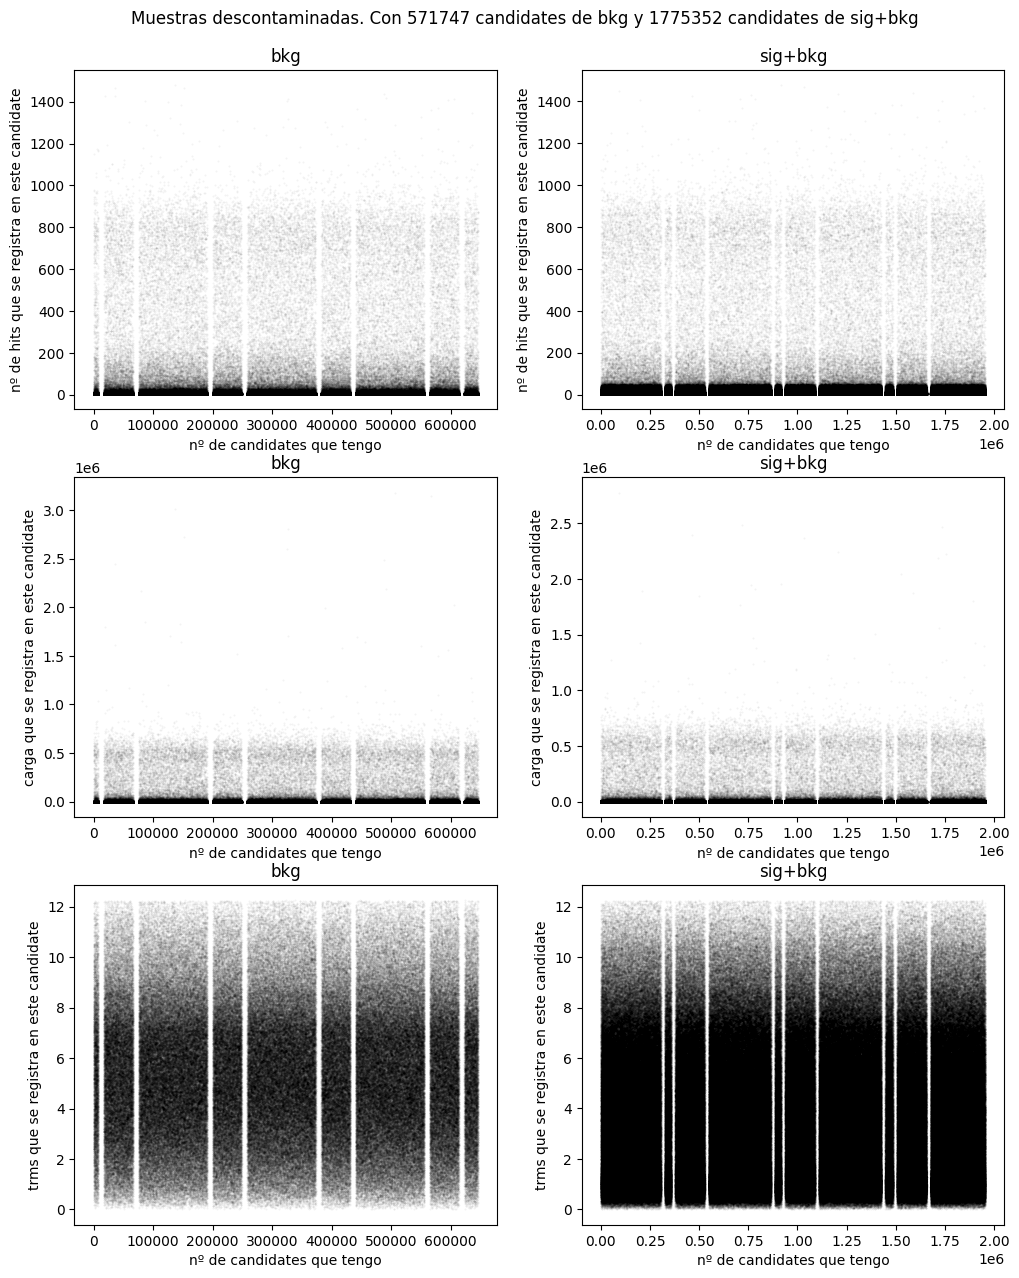

In [302]:
subplot = pltext.canvas(6)

subplot(1)
plt.scatter(total_nhits_by_candidate_bkg_clean.index, total_nhits_by_candidate_bkg_clean.values, s=0.2, alpha=0.05)
plt.xlabel("nº de candidates que tengo")
plt.ylabel("nº de hits que se registra en este candidate")
plt.title("bkg")

subplot(2)
plt.scatter(total_nhits_by_candidate_sig_clean.index, total_nhits_by_candidate_sig_clean.values, s=0.2, alpha=0.05)
plt.xlabel("nº de candidates que tengo")    
plt.ylabel("nº de hits que se registra en este candidate")
plt.title("sig+bkg")


subplot(3)
plt.scatter(total_charge_by_candidate_bkg_clean.index, total_charge_by_candidate_bkg_clean.values, s=0.2, alpha=0.05)
plt.xlabel("nº de candidates que tengo")
plt.ylabel("carga que se registra en este candidate")
plt.title("bkg")

subplot(4)
plt.scatter(total_charge_by_candidate_sig_clean.index, total_charge_by_candidate_sig_clean.values, s=0.2, alpha=0.05)
plt.xlabel("nº de candidates que tengo")
plt.ylabel("carga que se registra en este candidate")
plt.title("sig+bkg")


subplot(5)
plt.scatter(total_trms_by_candidate_bkg_clean.index, total_trms_by_candidate_bkg_clean.values, s=0.2, alpha=0.05)
plt.xlabel("nº de candidates que tengo")
plt.ylabel("trms que se registra en este candidate")
plt.title("bkg")

subplot(6)
plt.scatter(total_trms_by_candidate_sig_clean.index, total_trms_by_candidate_sig_clean.values, s=0.2, alpha=0.05)
plt.xlabel("nº de candidates que tengo")
plt.ylabel("trms que se registra en este candidate")
plt.title("sig+bkg")

plt.suptitle(f"Muestras descontaminadas. Con {len(total_nhits_by_candidate_bkg)-len(combined_series_bkg)} candidates de bkg y {len(total_nhits_by_candidate_sig)-len(combined_series_sig)} candidates de sig+bkg", y=0.92)

#plt.savefig(f"{output_directory}/Muestras_descontaminadas.png", dpi=500, bbox_inches="tight")

## Distribución de hits por candidate

Text(0.5, 0.98, 'Distribución de hits por candidates')

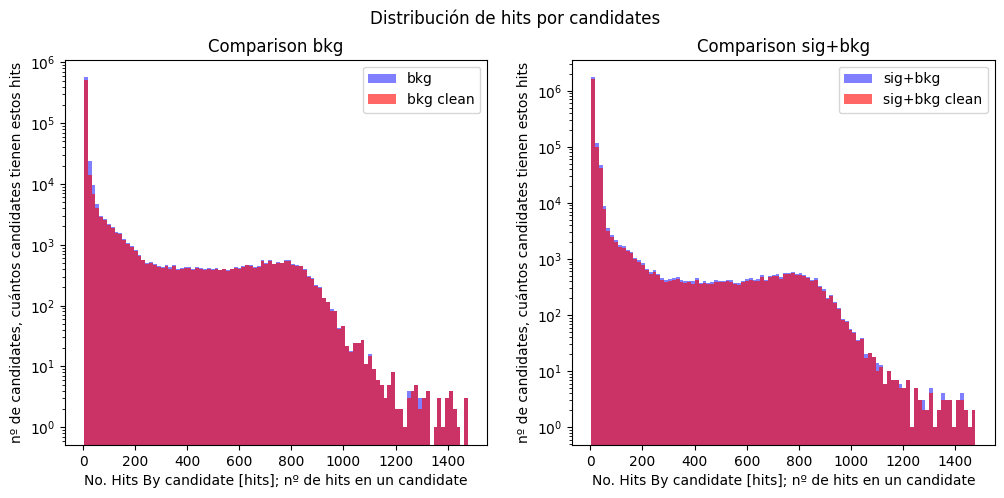

In [ ]:
subplot = pltext.canvas(2)
for i in [1, 2]:
    subplot(i)
    #plt.yscale("log")
    plt.yscale("log")

subplot(1)
plt.hist(total_nhits_by_candidate_bkg, 100, histtype="stepfilled", label="bkg", alpha=0.5, color="b")   #500 bins; histtype = "stepfilled" rellena el bin
plt.hist(total_nhits_by_candidate_bkg_clean, 100, histtype="stepfilled", label="bkg clean", alpha=0.6, color="r")
plt.xlabel("No. Hits By candidate [hits]; nº de hits en un candidate")
plt.ylabel("nº de candidates")
plt.title("Comparison bkg")
plt.legend()

subplot(2)
plt.hist(total_nhits_by_candidate_sig, 100, histtype="stepfilled", label="sig+bkg", alpha=0.5, color="b")
plt.hist(total_nhits_by_candidate_sig_clean, 100, histtype="stepfilled", label="sig+bkg clean", alpha=0.6, color="r")
plt.xlabel("No. Hits By candidate [hits]; nº de hits en un candidate")
plt.ylabel("nº de candidates")
plt.title("Comparison sig+bkg")
plt.legend()

plt.suptitle("Distribución de hits por candidates")

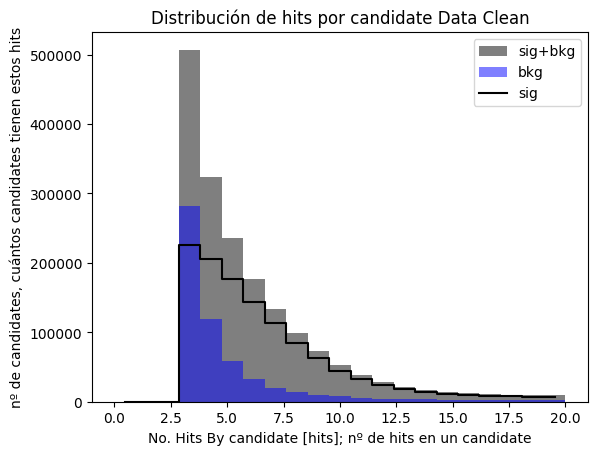

In [ ]:
counts_sig_nhits, edges_sig_nhits, _ = plt.hist(total_nhits_by_candidate_sig, 21, color="k", range=(0,20), histtype="stepfilled", alpha=0.5, label="sig+bkg")
counts_bkg_nhits, edges_bkg_nhits, _ = plt.hist(total_nhits_by_candidate_bkg, 21, color="b", range=(0,20), histtype = "stepfilled" ,alpha=0.5, label="bkg")

bin_centers_nhits = (edges_sig_nhits[:-1] + edges_sig_nhits [1:])/2   #divide entre 2 porque calcula el centro del bin
plt.step(bin_centers_nhits, counts_sig_nhits - counts_bkg_nhits, where="mid", label="sig", color="k") ;

plt.xlabel("No. Hits By candidate [hits]; nº de hits en un candidate")
plt.ylabel("nº de candidates")
plt.title("Distribución de hits por candidate Data Clean")
#plt.yscale("log")
plt.yscale("linear")
plt.legend()

## Distribución de carga total por candidate

Text(0.5, 0.98, 'Distribución de carga total por candidate')

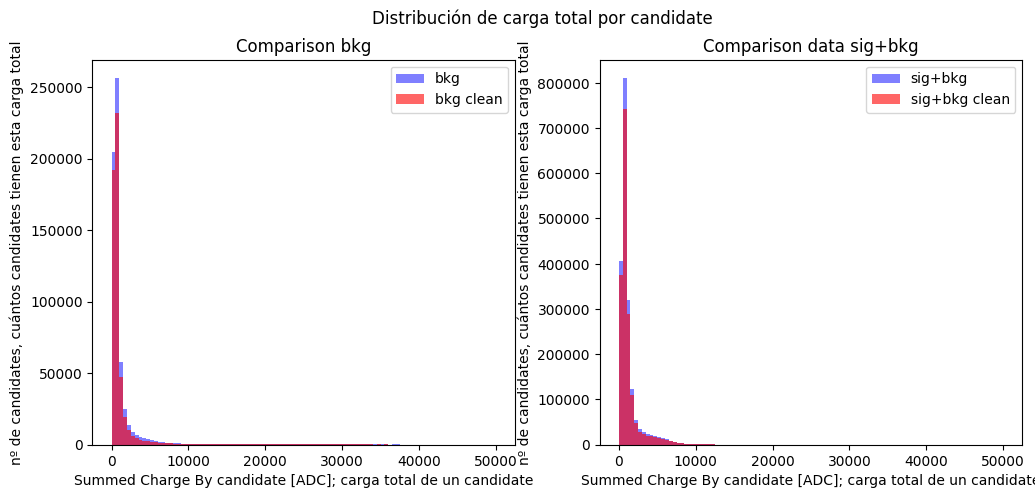

In [ ]:
subplot = pltext.canvas(2)
for i in [1, 2]:
    subplot(i)
    #plt.yscale("log")
    plt.yscale("linear")

hist_range = (0, 50e3)

subplot(1)
plt.hist(total_charge_by_candidate_bkg, 100, histtype="stepfilled", label="bkg", range=hist_range, alpha=0.5, color="b")   #100 bins; histtype = "step" dibuja el contorno de las barras
plt.hist(total_charge_by_candidate_bkg_clean, 100, histtype="stepfilled", label="bkg clean", range=hist_range, alpha=0.6, color="r")
plt.xlabel("Summed Charge By candidate [ADC]; carga total de un candidate")
plt.ylabel("nº de candidates")
plt.title("Comparison bkg")
plt.legend()

subplot(2)
plt.hist(total_charge_by_candidate_sig, 100, histtype="stepfilled", label="sig+bkg", range=hist_range, alpha=0.5, color="b")   #100 bins; histtype = "step" dibuja el contorno de las barras
plt.hist(total_charge_by_candidate_sig_clean, 100, histtype="stepfilled", label="sig+bkg clean", range=hist_range, alpha=0.6, color="r")
plt.xlabel("Summed Charge By candidate [ADC]; carga total de un candidate")
plt.ylabel("nº de candidates")
plt.title("Comparison data sig+bkg")
plt.legend()

plt.suptitle("Distribución de carga total por candidate")

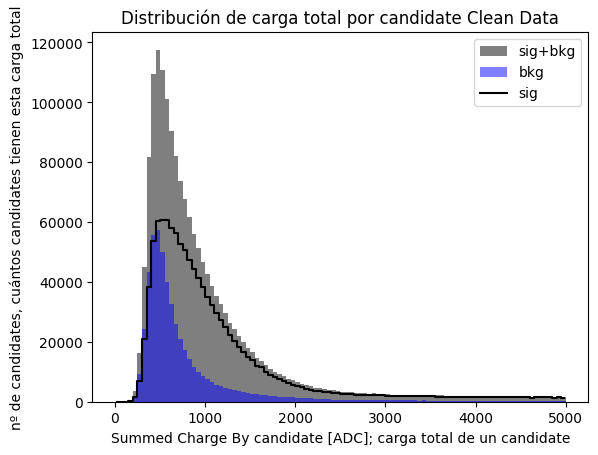

In [ ]:
counts_sig_charge, edges_sig_charge, _ = plt.hist(total_charge_by_candidate_sig_clean, 100,range=(0,5e3), color="k", histtype="stepfilled", alpha=0.5, label="sig+bkg")
counts_bkg_charge, edges_bkg_charge, _ = plt.hist(total_charge_by_candidate_bkg_clean, 100,range=(0,5e3), color="b", histtype = "stepfilled" ,alpha=0.5, label="bkg")    #recoge los valores x,y que dibuja en el histograma

bin_centers_charge = (edges_sig_charge[1:] + edges_sig_charge [:-1])/2   #divide entre 2 porque calcula el centro del bin
plt.step(bin_centers_charge, counts_sig_charge - counts_bkg_charge, where="mid", label="sig", color="k")

plt.xlabel("Summed Charge By candidate [ADC]; carga total de un candidate")
plt.ylabel("nº de candidates")
plt.title("Distribución de carga total por candidate Clean Data")
#plt.yscale("log")
plt.legend()

## Distribución de tRMS por candidate

Text(0.5, 0.98, 'Distribución de tRMS por candidate')

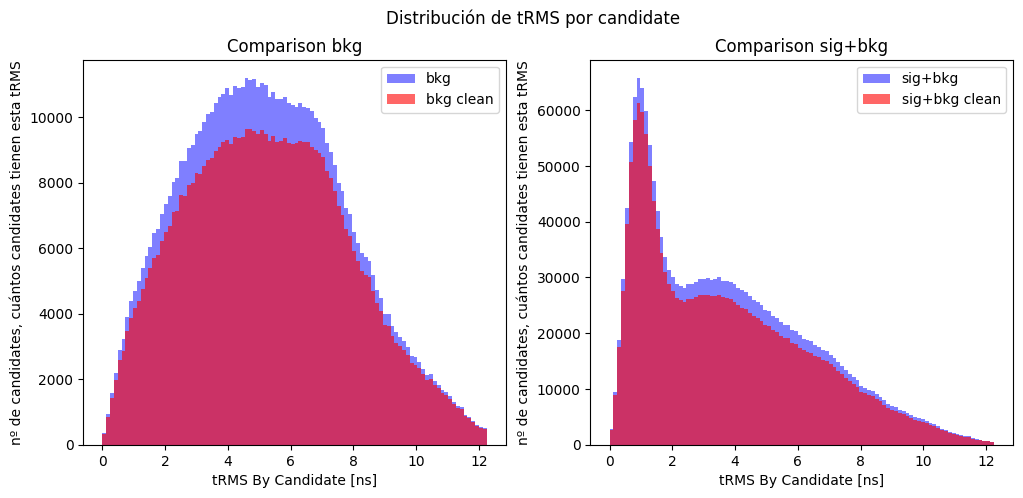

In [ ]:
subplot = pltext.canvas(2)

subplot(1)
plt.hist(total_trms_by_candidate_bkg, 100, histtype="stepfilled", alpha=0.5, label="bkg", color="b")
plt.hist(total_trms_by_candidate_bkg_clean, 100, histtype="stepfilled", alpha=0.6, label="bkg clean", color="r")
plt.xlabel("tRMS By Candidate [ns]")
plt.ylabel("nº de candidates")
plt.title("Comparison bkg")
#plt.yscale("log")
plt.legend()

subplot(2)
plt.hist(total_trms_by_candidate_sig, 100, histtype="stepfilled", alpha=0.5, label="sig+bkg", color="b")
plt.hist(total_trms_by_candidate_sig_clean, 100, histtype="stepfilled", alpha=0.6, label="sig+bkg clean", color="r")
plt.xlabel("tRMS By Candidate [ns]")
plt.ylabel("nº de candidates")
plt.title("Comparison sig+bkg")
#plt.yscale("log")
plt.legend()

plt.suptitle("Distribución de tRMS por candidate")



La tRMS es la desviación estándar de los tiempos de llegada de los hits en un candidate. Si los hits que forman un candidate llegaran a la vez, el tRMS sería cero, i.e., cuanto más dispersos en el tiempo, mayor será la tRMS. Vemos que el pico corresponde a que hay muchos candidates con tRMS pequeña (los hits llegan casi a la vez). Que haya esta diferencia tan marcada entre bkg y sig+bkg sugiere que el detector tiene buena resolución para identificar candidates deseados basándose en el tiempo.

Si quiero hacer un corte para quedarme solo con los candidates más probables de ser reales lo haría en tRMS < 2 [ns]: conservo gran parte de sig (pico) y elimino gran parte del bkg.

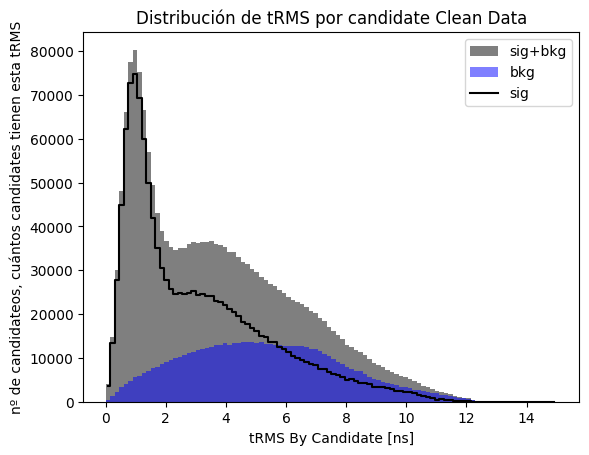

In [ ]:
counts_sig_trms, edges_sig_trms, _ = plt.hist(total_trms_by_candidate_sig, 100, range=(0,15), histtype="stepfilled", alpha=0.5, label="sig+bkg")
counts_bkg_trms, edges_bkg_trms, _ = plt.hist(total_trms_by_candidate_bkg, 100, range=(0,15), histtype = "stepfilled" ,alpha=0.5, label="bkg")

bin_centers_trms = (edges_sig_trms[:-1] + edges_sig_trms [1:])/2   #divide entre 2 porque calcula el centro del bin
plt.step(bin_centers_trms, counts_sig_trms - counts_bkg_trms, where="mid", label="sig", color="k") ; #Esto que plotea ya es la resta bin a bin, pero no era que no tenían la misma longitud???

plt.title("Distribución de tRMS por candidate Clean Data")
plt.xlabel("tRMS By Candidate [ns]")
plt.ylabel("nº de candidates")
plt.legend()

#plt.yscale("log")

# RECAP DE LOS PLOTS CON CLEAN DATA

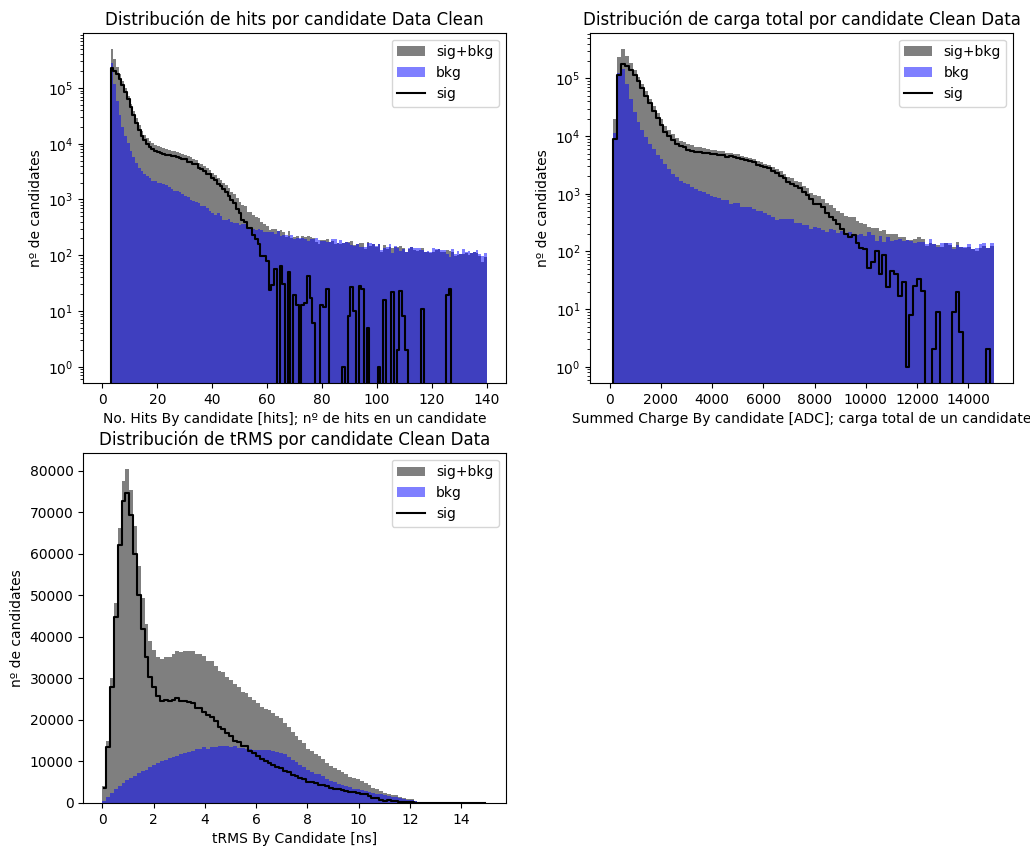

In [378]:
subplot = pltext.canvas(3)

for i in [1, 2]:
    subplot(i)
    #plt.yscale("linear")
    plt.yscale("log")

subplot(1)
# counts_sig_nhits, edges_sig_nhits, _ = plt.hist(total_nhits_by_candidate_sig, 21, color="k", range=(0,20), histtype="stepfilled", alpha=0.5, label="sig+bkg")
# counts_bkg_nhits, edges_bkg_nhits, _ = plt.hist(total_nhits_by_candidate_bkg, 21, color="b", range=(0,20), histtype = "stepfilled" ,alpha=0.5, label="bkg")
counts_sig_nhits, edges_sig_nhits, _ = plt.hist(total_nhits_by_candidate_sig, 141, color="k", range=(0,140), histtype="stepfilled", alpha=0.5, label="sig+bkg")
counts_bkg_nhits, edges_bkg_nhits, _ = plt.hist(total_nhits_by_candidate_bkg, 141, color="b", range=(0,140), histtype = "stepfilled" ,alpha=0.5, label="bkg")

bin_centers_nhits = (edges_sig_nhits[:-1] + edges_sig_nhits [1:])/2   #divide entre 2 porque calcula el centro del bin
plt.step(bin_centers_nhits, counts_sig_nhits - counts_bkg_nhits, where="mid", label="sig", color="k") ;

plt.xlabel("No. Hits By candidate [hits]; nº de hits en un candidate")
plt.ylabel("nº de candidates")
plt.title("Distribución de hits por candidate Data Clean")
plt.legend()

subplot(2)
counts_sig_charge, edges_sig_charge, _ = plt.hist(total_charge_by_candidate_sig_clean, 100,range=(0,1.5e4), color="k", histtype="stepfilled", alpha=0.5, label="sig+bkg")
counts_bkg_charge, edges_bkg_charge, _ = plt.hist(total_charge_by_candidate_bkg_clean, 100,range=(0,1.5e4), color="b", histtype = "stepfilled" ,alpha=0.5, label="bkg")    #recoge los valores x,y que dibuja en el histograma

bin_centers_charge = (edges_sig_charge[1:] + edges_sig_charge [:-1])/2   #divide entre 2 porque calcula el centro del bin
plt.step(bin_centers_charge, counts_sig_charge - counts_bkg_charge, where="mid", label="sig", color="k")

plt.xlabel("Summed Charge By candidate [ADC]; carga total de un candidate")
plt.ylabel("nº de candidates")
plt.title("Distribución de carga total por candidate Clean Data")
plt.legend()

subplot(3)
counts_sig_trms, edges_sig_trms, _ = plt.hist(total_trms_by_candidate_sig, 100, range=(0,15), histtype="stepfilled", alpha=0.5, label="sig+bkg")
counts_bkg_trms, edges_bkg_trms, _ = plt.hist(total_trms_by_candidate_bkg, 100, range=(0,15), histtype = "stepfilled" ,alpha=0.5, label="bkg")

bin_centers_trms = (edges_sig_trms[:-1] + edges_sig_trms [1:])/2   #divide entre 2 porque calcula el centro del bin
plt.step(bin_centers_trms, counts_sig_trms - counts_bkg_trms, where="mid", label="sig", color="k") ; #Esto que plotea ya es la resta bin a bin, pero no era que no tenían la misma longitud???

plt.title("Distribución de tRMS por candidate Clean Data")
plt.xlabel("tRMS By Candidate [ns]")
plt.ylabel("nº de candidates")
plt.legend()

# CORTES CON MASKS

## Cortes en nhits por candidate

In [365]:
#hago los cortes: busco los candidates con número de hits entre 5(10) y 60 hits.
#busco una serie de valores True/False que te me diga qué filas quiero conservar y cuáles no: una mask
#tengo q hacer dos para los dos límites inferiores que me pidieron

mask_5_bkg = (total_nhits_by_candidate_bkg_clean > 5) & (total_nhits_by_candidate_bkg_clean <= 60)
mask_5_sig = (total_nhits_by_candidate_sig_clean > 5) & (total_nhits_by_candidate_sig_clean <= 60)  #no puedo usar la misma máscara para los dos porq son series diferentes

mask_10_bkg = (total_nhits_by_candidate_bkg_clean > 10) & (total_nhits_by_candidate_bkg_clean <= 60)
mask_10_sig = (total_nhits_by_candidate_sig_clean > 10) & (total_nhits_by_candidate_sig_clean <= 60)


total_nhits_by_candidate_sig_clean_mask_5 = total_nhits_by_candidate_sig_clean[mask_5_sig]
total_nhits_by_candidate_bkg_clean_mask_5 = total_nhits_by_candidate_bkg_clean[mask_5_bkg]

total_nhits_by_candidate_sig_clean_mask_10 = total_nhits_by_candidate_sig_clean[mask_10_sig]
total_nhits_by_candidate_bkg_clean_mask_10 = total_nhits_by_candidate_bkg_clean[mask_10_bkg]

total_charge_by_candidate_sig_clean_mask_5 = total_charge_by_candidate_sig_clean.loc[total_nhits_by_candidate_sig_clean_mask_5.index]
total_charge_by_candidate_bkg_clean_mask_5 = total_charge_by_candidate_bkg_clean.loc[total_nhits_by_candidate_bkg_clean_mask_5.index]

total_charge_by_candidate_sig_clean_mask_10 = total_charge_by_candidate_sig_clean.loc[total_nhits_by_candidate_sig_clean_mask_10.index]
total_charge_by_candidate_bkg_clean_mask_10 = total_charge_by_candidate_bkg_clean.loc[total_nhits_by_candidate_bkg_clean_mask_10.index]

total_trms_by_candidate_sig_clean_mask_5 = total_trms_by_candidate_sig_clean.loc[total_nhits_by_candidate_sig_clean_mask_5.index]
total_trms_by_candidate_bkg_clean_mask_5 = total_trms_by_candidate_bkg_clean.loc[total_nhits_by_candidate_bkg_clean_mask_5.index]

total_trms_by_candidate_sig_clean_mask_10 = total_trms_by_candidate_sig_clean.loc[total_nhits_by_candidate_sig_clean_mask_10.index]
total_trms_by_candidate_bkg_clean_mask_10 = total_trms_by_candidate_bkg_clean.loc[total_nhits_by_candidate_bkg_clean_mask_10.index]

Text(0.5, 0.92, 'Cuts con masks para nhits')

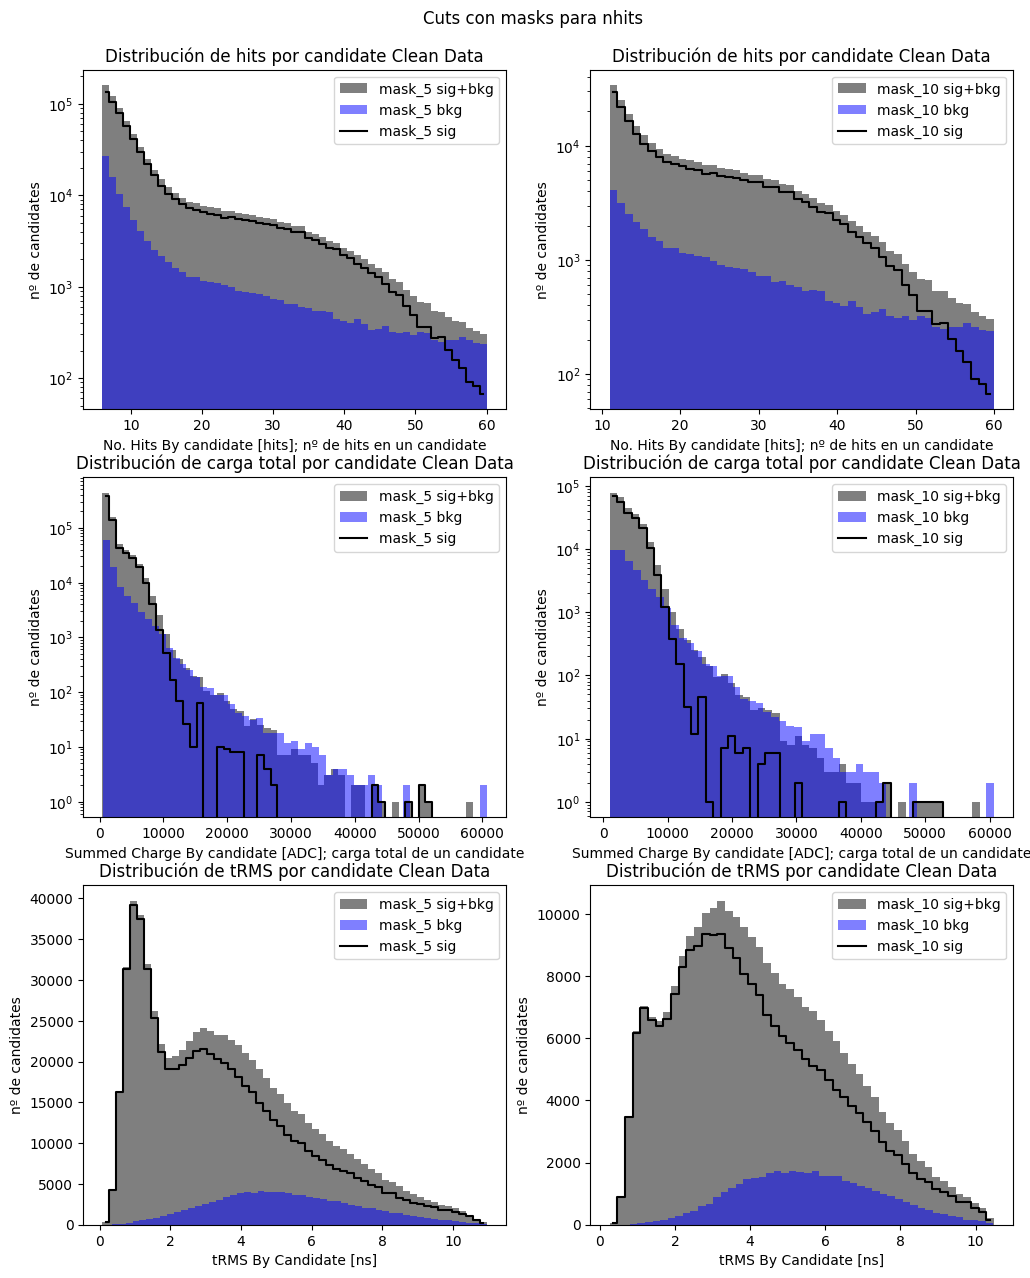

In [384]:
subplot = pltext.canvas(6)

subplot(1)
counts_sig_nhits_mask_5, edges_sig_nhits_mask_5, _ = plt.hist(total_nhits_by_candidate_sig_clean_mask_5, 55, histtype="stepfilled", alpha=0.5, label="mask_5 sig+bkg") #55 es el máximo sin que haya bins vacíos
counts_bkg_nhits_mask_5, edges_bkg_nhits_mask_5, _ = plt.hist(total_nhits_by_candidate_bkg_clean_mask_5, 55, histtype = "stepfilled" ,alpha=0.5, label="mask_5 bkg")

bin_centers_nhits_mask_5 = (edges_sig_nhits_mask_5[:-1] + edges_sig_nhits_mask_5 [1:])/2   #divide entre 2 porque calcula el centro del bin
plt.step(bin_centers_nhits_mask_5, counts_sig_nhits_mask_5 - counts_bkg_nhits_mask_5, where="mid", label="mask_5 sig", color="k") ;

plt.xlabel("No. Hits By candidate [hits]; nº de hits en un candidate")
plt.ylabel("nº de candidates")
plt.title("Distribución de hits por candidate Clean Data")
plt.yscale("log")
plt.legend()

subplot(2)
counts_sig_nhits_mask_10, edges_sig_nhits_mask_10, _ = plt.hist(total_nhits_by_candidate_sig_clean_mask_10, 50, histtype="stepfilled", alpha=0.5, label="mask_10 sig+bkg") #50 es el máximo sin que haya bins vacíos
counts_bkg_nhits_mask_10, edges_bkg_nhits_mask_10, _ = plt.hist(total_nhits_by_candidate_bkg_clean_mask_10, 50, histtype = "stepfilled" ,alpha=0.5, label="mask_10 bkg")

bin_centers_nhits_mask_10 = (edges_sig_nhits_mask_10[:-1] + edges_sig_nhits_mask_10 [1:])/2   #divide entre 2 porque calcula el centro del bin
plt.step(bin_centers_nhits_mask_10, counts_sig_nhits_mask_10 - counts_bkg_nhits_mask_10, where="mid", label="mask_10 sig", color="k") ;

plt.xlabel("No. Hits By candidate [hits]; nº de hits en un candidate")
plt.ylabel("nº de candidates")
plt.title("Distribución de hits por candidate Clean Data")
plt.yscale("log")
plt.legend()

subplot(3)
counts_sig_charge_mask_5, edges_sig_charge_mask_5, _ = plt.hist(total_charge_by_candidate_sig_clean_mask_5, 55, histtype="stepfilled", alpha=0.5, label="mask_5 sig+bkg") #55 bins según nhits
counts_bkg_charge_mask_5, edges_bkg_charge_mask_5, _ = plt.hist(total_charge_by_candidate_bkg_clean_mask_5, 55, histtype = "stepfilled" ,alpha=0.5, label="mask_5 bkg")

bin_centers_charge_mask_5 = (edges_sig_charge_mask_5[:-1] + edges_sig_charge_mask_5 [1:])/2   #divide entre 2 porque calcula el centro del bin
plt.step(bin_centers_charge_mask_5, counts_sig_charge_mask_5 - counts_bkg_charge_mask_5, where="mid", label="mask_5 sig", color="k") 

plt.xlabel("Summed Charge By candidate [ADC]; carga total de un candidate")
plt.ylabel("nº de candidates")
plt.title("Distribución de carga total por candidate Clean Data")
plt.yscale("log")
plt.legend()

subplot(4)
counts_sig_charge_mask_10, edges_sig_charge_mask_10, _ = plt.hist(total_charge_by_candidate_sig_clean_mask_10, 50, histtype="stepfilled", alpha=0.5, label="mask_10 sig+bkg") #50 bins según nhits
counts_bkg_charge_mask_10, edges_bkg_charge_mask_10, _ = plt.hist(total_charge_by_candidate_bkg_clean_mask_10, 50, histtype = "stepfilled" ,alpha=0.5, label="mask_10 bkg")

bin_centers_charge_mask_10 = (edges_sig_charge_mask_10[:-1] + edges_sig_charge_mask_10 [1:])/2   #divide entre 2 porque calcula el centro del bin
plt.step(bin_centers_charge_mask_10, counts_sig_charge_mask_10 - counts_bkg_charge_mask_10, where="mid", label="mask_10 sig", color="k") 

plt.xlabel("Summed Charge By candidate [ADC]; carga total de un candidate")
plt.ylabel("nº de candidates")
plt.title("Distribución de carga total por candidate Clean Data")
plt.yscale("log")
plt.legend()

subplot(5)#para trms
counts_sig_trms_mask_5, edges_sig_trms_mask_5, _ = plt.hist(total_trms_by_candidate_sig_clean_mask_5, 55, histtype="stepfilled", alpha=0.5, label="mask_5 sig+bkg") #55 bins según nhits
counts_bkg_trms_mask_5, edges_bkg_trms_mask_5, _ = plt.hist(total_trms_by_candidate_bkg_clean_mask_5, 55, histtype = "stepfilled" ,alpha=0.5, label="mask_5 bkg")

bin_centers_trms_mask_5 = (edges_sig_trms_mask_5[:-1] + edges_sig_trms_mask_5 [1:])/2   #divide entre 2 porque calcula el centro del bin
plt.step(bin_centers_trms_mask_5, counts_sig_trms_mask_5 - counts_bkg_trms_mask_5, where="mid", label="mask_5 sig", color="k") 

plt.title("Distribución de tRMS por candidate Clean Data")
plt.xlabel("tRMS By Candidate [ns]")
plt.ylabel("nº de candidates")
plt.legend()
#plt.yscale("log")

subplot(6)
counts_sig_trms_mask_10, edges_sig_trms_mask_10, _ = plt.hist(total_trms_by_candidate_sig_clean_mask_10, 50, histtype="stepfilled", alpha=0.5, label="mask_10 sig+bkg") #50 bins según nhits
counts_bkg_trms_mask_10, edges_bkg_trms_mask_10, _ = plt.hist(total_trms_by_candidate_bkg_clean_mask_10, 50, histtype = "stepfilled" ,alpha=0.5, label="mask_10 bkg")

bin_centers_trms_mask_10 = (edges_sig_trms_mask_10[:-1] + edges_sig_trms_mask_10 [1:])/2   #divide entre 2 porque calcula el centro del bin
plt.step(bin_centers_trms_mask_10, counts_sig_trms_mask_10 - counts_bkg_trms_mask_10, where="mid", label="mask_10 sig", color="k") 
plt.title("Distribución de tRMS por candidate Clean Data")
plt.xlabel("tRMS By Candidate [ns]")
plt.ylabel("nº de candidates")
plt.legend()
#plt.yscale("log")

plt.suptitle("Cuts con masks para nhits", y=0.92)


## Corte en carga total por candidate

In [382]:
#hago los cortes: busco los candidate con carga entre 0 y 100000 [ADC]. Creo que es mejor establecer 10000
#busco una serie de valores True/False que te me diga qué filas quiero conservar y cuáles no: una mask
#tengo q hacer dos para los dos límites inferiores que me pidieron

mask_charge_bkg = (total_charge_by_candidate_bkg_clean > 0) & (total_charge_by_candidate_bkg_clean <= 10000)
mask_charge_sig = (total_charge_by_candidate_sig_clean > 0) & (total_charge_by_candidate_sig_clean <= 10000)  #no puedo usar la misma máscara para los dos porq son series diferentes

total_charge_by_candidate_sig_clean_mask_charge = total_charge_by_candidate_sig_clean[mask_charge_sig]
total_charge_by_candidate_bkg_clean_mask_charge = total_charge_by_candidate_bkg_clean[mask_charge_bkg]

total_nhits_by_candidate_sig_clean_mask_charge = total_nhits_by_candidate_sig_clean.loc[total_charge_by_candidate_sig_clean_mask_charge.index]
total_nhits_by_candidate_bkg_clean_mask_charge = total_nhits_by_candidate_bkg_clean.loc[total_charge_by_candidate_bkg_clean_mask_charge.index]

total_trms_by_candidate_sig_clean_mask_charge = total_trms_by_candidate_sig_clean.loc[total_charge_by_candidate_sig_clean_mask_charge.index]
total_trms_by_candidate_bkg_clean_mask_charge = total_trms_by_candidate_bkg_clean.loc[total_charge_by_candidate_bkg_clean_mask_charge.index]

Text(0.5, 0.96, 'Cuts con masks para charge')

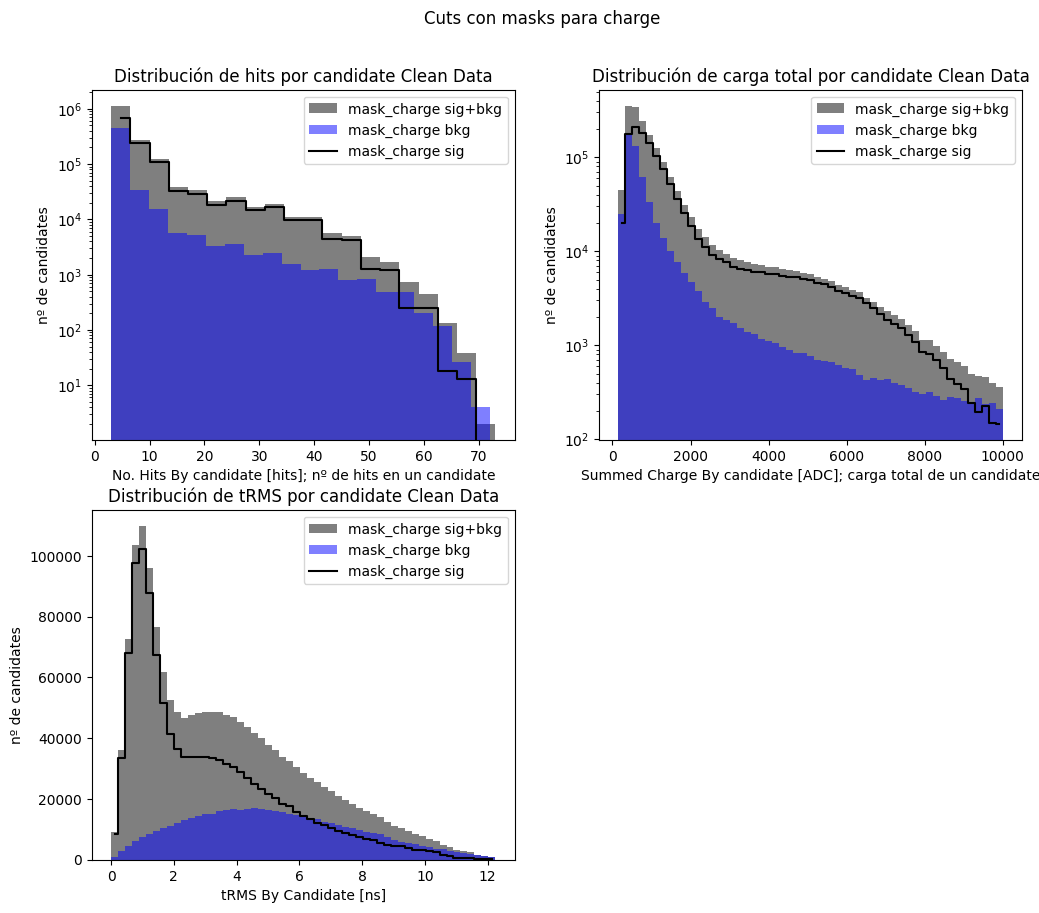

In [389]:
subplot = pltext.canvas(3)

subplot(1)
counts_sig_nhits_mask_charge, edges_sig_nhits_mask_charge, _ = plt.hist(total_nhits_by_candidate_sig_clean_mask_charge, 20, histtype="stepfilled", alpha=0.5, label="mask_charge sig+bkg") #55 es el máximo sin que haya bins vacíos
counts_bkg_nhits_mask_charge, edges_bkg_nhits_mask_charge, _ = plt.hist(total_nhits_by_candidate_bkg_clean_mask_charge, 20, histtype = "stepfilled" ,alpha=0.5, label="mask_charge bkg")

bin_centers_nhits_mask_charge = (edges_sig_nhits_mask_charge[:-1] + edges_sig_nhits_mask_charge [1:])/2   #divide entre 2 porque calcula el centro del bin
plt.step(bin_centers_nhits_mask_charge, counts_sig_nhits_mask_charge - counts_bkg_nhits_mask_charge, where="mid", label="mask_charge sig", color="k") ;

plt.xlabel("No. Hits By candidate [hits]; nº de hits en un candidate")
plt.ylabel("nº de candidates")
plt.title("Distribución de hits por candidate Clean Data")
plt.yscale("log")
plt.legend()


subplot(2)
counts_sig_charge_mask_charge, edges_sig_charge_mask_charge, _ = plt.hist(total_charge_by_candidate_sig_clean_mask_charge, 55, histtype="stepfilled", alpha=0.5, label="mask_charge sig+bkg") #55 bins según nhits
counts_bkg_charge_mask_charge, edges_bkg_charge_mask_charge, _ = plt.hist(total_charge_by_candidate_bkg_clean_mask_charge, 55, histtype = "stepfilled" ,alpha=0.5, label="mask_charge bkg")

bin_centers_charge_mask_charge = (edges_sig_charge_mask_charge[:-1] + edges_sig_charge_mask_charge [1:])/2   #divide entre 2 porque calcula el centro del bin
plt.step(bin_centers_charge_mask_charge, counts_sig_charge_mask_charge - counts_bkg_charge_mask_charge, where="mid", label="mask_charge sig", color="k") 

plt.xlabel("Summed Charge By candidate [ADC]; carga total de un candidate")
plt.ylabel("nº de candidates")
plt.title("Distribución de carga total por candidate Clean Data")
plt.yscale("log")
plt.legend()
#plt.xlim(0,100000)


subplot(3)#para trms
counts_sig_trms_mask_charge, edges_sig_trms_mask_charge, _ = plt.hist(total_trms_by_candidate_sig_clean_mask_charge, 55, histtype="stepfilled", alpha=0.5, label="mask_charge sig+bkg") #55 bins según nhits
counts_bkg_trms_mask_charge, edges_bkg_trms_mask_charge, _ = plt.hist(total_trms_by_candidate_bkg_clean_mask_charge, 55, histtype = "stepfilled" ,alpha=0.5, label="mask_charge bkg")

bin_centers_trms_mask_charge = (edges_sig_trms_mask_charge[:-1] + edges_sig_trms_mask_charge [1:])/2   #divide entre 2 porque calcula el centro del bin
plt.step(bin_centers_trms_mask_charge, counts_sig_trms_mask_charge - counts_bkg_trms_mask_charge, where="mid", label="mask_charge sig", color="k") 

plt.title("Distribución de tRMS por candidate Clean Data")
plt.xlabel("tRMS By Candidate [ns]")
plt.ylabel("nº de candidates")
plt.legend()
#plt.yscale("log")


plt.suptitle("Cuts con masks para charge", y=0.96)


## Corte en tRMS por candidate

In [397]:
#hago los cortes: busco los candidateos con carga entre 0 y 7 [ns].
#busco una serie de valores True/False que te me diga qué filas quiero conservar y cuáles no: una mask
#tengo q hacer dos para los dos límites inferiores que me pidieron

mask_trms_bkg = (total_trms_by_candidate_bkg_clean > 0) & (total_trms_by_candidate_bkg_clean <= 7)
mask_trms_sig = (total_trms_by_candidate_sig_clean > 0) & (total_trms_by_candidate_sig_clean <= 7)  #no puedo usar la misma máscara para los dos porq son series diferentes

total_trms_by_candidate_sig_clean_mask_trms = total_trms_by_candidate_sig_clean[mask_trms_sig]
total_trms_by_candidate_bkg_clean_mask_trms = total_trms_by_candidate_bkg_clean[mask_trms_bkg]

total_nhits_by_candidate_sig_clean_mask_trms = total_nhits_by_candidate_sig_clean.loc[total_trms_by_candidate_sig_clean_mask_trms.index]
total_nhits_by_candidate_bkg_clean_mask_trms = total_nhits_by_candidate_bkg_clean.loc[total_trms_by_candidate_bkg_clean_mask_trms.index]

total_charge_by_candidate_sig_clean_mask_trms = total_charge_by_candidate_sig_clean.loc[total_trms_by_candidate_sig_clean_mask_trms.index]
total_charge_by_candidate_bkg_clean_mask_trms = total_charge_by_candidate_bkg_clean.loc[total_trms_by_candidate_bkg_clean_mask_trms.index]

Text(0.5, 0.96, 'Cuts con masks para tRMS')

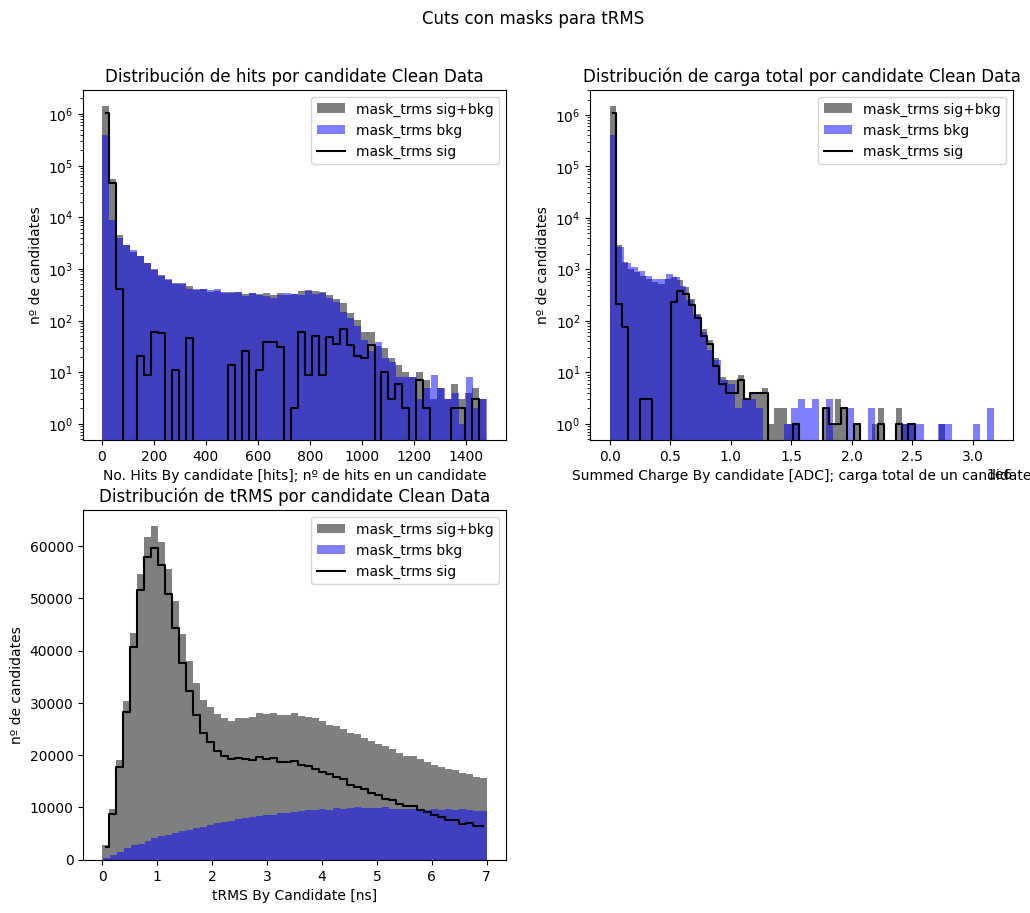

In [398]:
subplot = pltext.canvas(3)

subplot(1)
counts_sig_nhits_mask_trms, edges_sig_nhits_mask_trms, _ = plt.hist(total_nhits_by_candidate_sig_clean_mask_trms, 55, histtype="stepfilled", alpha=0.5, label="mask_trms sig+bkg") #55 es el máximo sin que haya bins vacíos
counts_bkg_nhits_mask_trms, edges_bkg_nhits_mask_trms, _ = plt.hist(total_nhits_by_candidate_bkg_clean_mask_trms, 55, histtype = "stepfilled" ,alpha=0.5, label="mask_trms bkg")

bin_centers_nhits_mask_trms = (edges_sig_nhits_mask_trms[:-1] + edges_sig_nhits_mask_trms [1:])/2   #divide entre 2 porque calcula el centro del bin
plt.step(bin_centers_nhits_mask_trms, counts_sig_nhits_mask_trms - counts_bkg_nhits_mask_trms, where="mid", label="mask_trms sig", color="k") ;

plt.xlabel("No. Hits By candidate [hits]; nº de hits en un candidate")
plt.ylabel("nº de candidates")
plt.title("Distribución de hits por candidate Clean Data")
plt.yscale("log")
plt.legend()


subplot(2)
counts_sig_charge_mask_trms, edges_sig_charge_mask_trms, _ = plt.hist(total_charge_by_candidate_sig_clean_mask_trms, 55, histtype="stepfilled", alpha=0.5, label="mask_trms sig+bkg") #55 bins según nhits
counts_bkg_charge_mask_trms, edges_bkg_charge_mask_trms, _ = plt.hist(total_charge_by_candidate_bkg_clean_mask_trms, 55, histtype = "stepfilled" ,alpha=0.5, label="mask_trms bkg")

bin_centers_charge_mask_trms = (edges_sig_charge_mask_trms[:-1] + edges_sig_charge_mask_trms [1:])/2   #divide entre 2 porque calcula el centro del bin
plt.step(bin_centers_charge_mask_trms, counts_sig_charge_mask_trms - counts_bkg_charge_mask_trms, where="mid", label="mask_trms sig", color="k") 

plt.xlabel("Summed Charge By candidate [ADC]; carga total de un candidate")
plt.ylabel("nº de candidates")
plt.title("Distribución de carga total por candidate Clean Data")
plt.yscale("log")
plt.legend()


subplot(3)#para trms
counts_sig_trms_mask_trms, edges_sig_trms_mask_trms, _ = plt.hist(total_trms_by_candidate_sig_clean_mask_trms, 55, histtype="stepfilled", alpha=0.5, label="mask_trms sig+bkg") #55 bins según nhits
counts_bkg_trms_mask_trms, edges_bkg_trms_mask_trms, _ = plt.hist(total_trms_by_candidate_bkg_clean_mask_trms, 55, histtype = "stepfilled" ,alpha=0.5, label="mask_trms bkg")

bin_centers_trms_mask_trms = (edges_sig_trms_mask_trms[:-1] + edges_sig_trms_mask_trms [1:])/2   #divide entre 2 porque calcula el centro del bin
plt.step(bin_centers_trms_mask_trms, counts_sig_trms_mask_trms - counts_bkg_trms_mask_trms, where="mid", label="mask_trms sig", color="k") 

plt.title("Distribución de tRMS por candidate Clean Data")
plt.xlabel("tRMS By Candidate [ns]")
plt.ylabel("nº de candidates")
plt.legend()
#plt.yscale("log")


plt.suptitle("Cuts con masks para tRMS", y=0.96)


## Cortes nhits + tRMS por candidate

In [399]:
#mask_total_1 = corte de 5 a 60 nhits + corte de 0 a 7 [ns] en trms, la aplicamos en bkg y en sig+bkg

mask_total_1_bkg = (total_nhits_by_candidate_bkg_clean > 5) & (total_nhits_by_candidate_bkg_clean <= 60) & (total_trms_by_candidate_bkg_clean > 0) & (total_trms_by_candidate_bkg_clean <= 7)
mask_total_1_sig = (total_nhits_by_candidate_sig_clean > 5) & (total_nhits_by_candidate_sig_clean <= 60) & (total_trms_by_candidate_sig_clean > 0) & (total_trms_by_candidate_sig_clean <= 7)

total_nhits_by_candidate_bkg_clean_mask_total_1 = total_nhits_by_candidate_bkg_clean[mask_total_1_bkg]
total_trms_by_candidate_bkg_clean_mask_total_1 = total_trms_by_candidate_bkg_clean[mask_total_1_bkg]
total_charge_by_candidate_bkg_clean_mask_total_1 = total_charge_by_candidate_bkg_clean[mask_total_1_bkg]

total_nhits_by_candidate_sig_clean_mask_total_1 = total_nhits_by_candidate_sig_clean[mask_total_1_sig]
total_trms_by_candidate_sig_clean_mask_total_1 = total_trms_by_candidate_sig_clean[mask_total_1_sig]
total_charge_by_candidate_sig_clean_mask_total_1 = total_charge_by_candidate_sig_clean[mask_total_1_sig]

#mask_total_2 = corte de 10 a 60 nhits + corte de 0 a 7 [ns] en trms, la aplicamos en bkg y en sig+bkg

mask_total_2_bkg = (total_nhits_by_candidate_bkg_clean > 10) & (total_nhits_by_candidate_bkg_clean <= 60) & (total_trms_by_candidate_bkg_clean > 0) & (total_trms_by_candidate_bkg_clean <= 7)
mask_total_2_sig = (total_nhits_by_candidate_sig_clean > 10) & (total_nhits_by_candidate_sig_clean <= 60) & (total_trms_by_candidate_sig_clean > 0) & (total_trms_by_candidate_sig_clean <= 7)

total_nhits_by_candidate_bkg_clean_mask_total_2 = total_nhits_by_candidate_bkg_clean[mask_total_2_bkg]
total_trms_by_candidate_bkg_clean_mask_total_2 = total_trms_by_candidate_bkg_clean[mask_total_2_bkg]
total_charge_by_candidate_bkg_clean_mask_total_2 = total_charge_by_candidate_bkg_clean[mask_total_2_bkg]

total_nhits_by_candidate_sig_clean_mask_total_2 = total_nhits_by_candidate_sig_clean[mask_total_2_sig]
total_trms_by_candidate_sig_clean_mask_total_2 = total_trms_by_candidate_sig_clean[mask_total_2_sig]
total_charge_by_candidate_sig_clean_mask_total_2 = total_charge_by_candidate_sig_clean[mask_total_2_sig]

Text(0.5, 0.96, 'Cuts con mask_total_1 = nhits (5,60) & tRMS (0,7)')

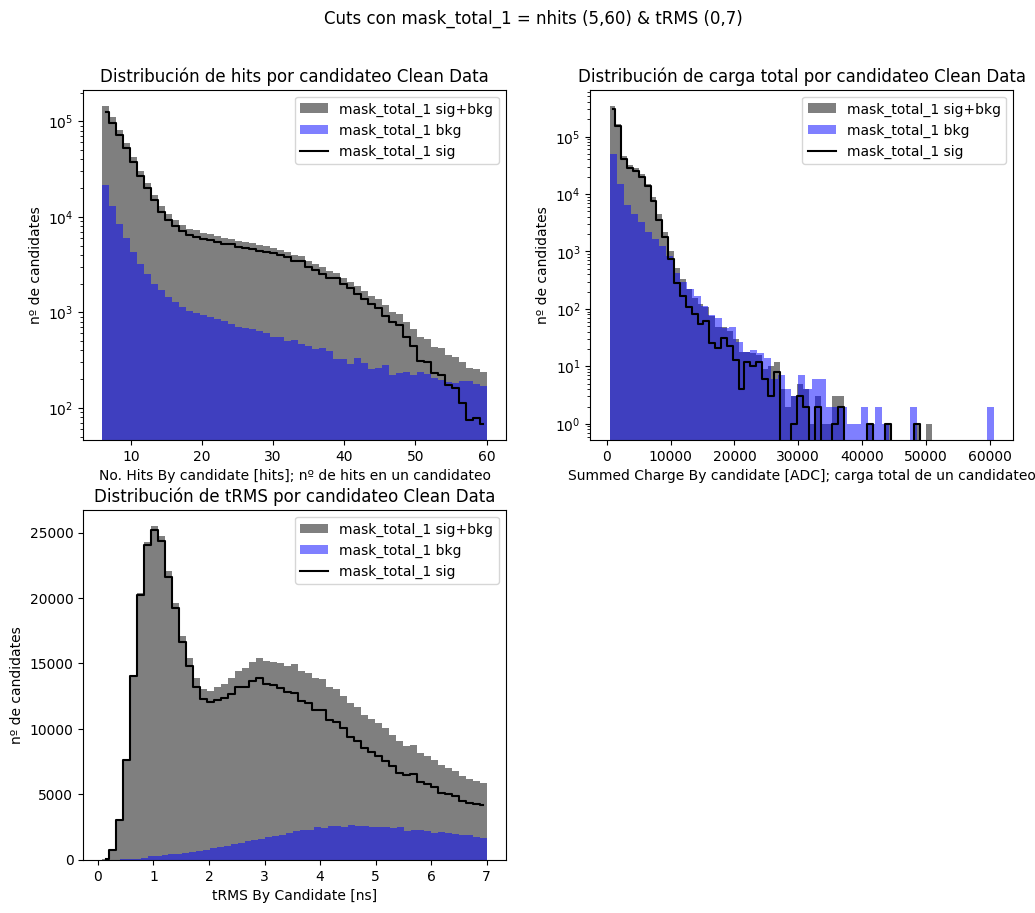

In [400]:
subplot = pltext.canvas(3)

subplot(1)
counts_sig_nhits_mask_total_1, edges_sig_nhits_mask_total_1, _ = plt.hist(total_nhits_by_candidate_sig_clean_mask_total_1, 55, histtype="stepfilled", alpha=0.5, label="mask_total_1 sig+bkg") #55 es el máximo sin que haya bins vacíos
counts_bkg_nhits_mask_total_1, edges_bkg_nhits_mask_total_1, _ = plt.hist(total_nhits_by_candidate_bkg_clean_mask_total_1, 55, histtype = "stepfilled" ,alpha=0.5, label="mask_total_1 bkg")

bin_centers_nhits_mask_total_1 = (edges_sig_nhits_mask_total_1[:-1] + edges_sig_nhits_mask_total_1 [1:])/2   #divide entre 2 porque calcula el centro del bin
plt.step(bin_centers_nhits_mask_total_1, counts_sig_nhits_mask_total_1 - counts_bkg_nhits_mask_total_1, where="mid", label="mask_total_1 sig", color="k") ;

plt.xlabel("No. Hits By candidate [hits]; nº de hits en un candidateo")
plt.ylabel("nº de candidates")
plt.title("Distribución de hits por candidateo Clean Data")
plt.yscale("log")
plt.legend()


subplot(2)
counts_sig_charge_mask_total_1, edges_sig_charge_mask_total_1, _ = plt.hist(total_charge_by_candidate_sig_clean_mask_total_1, 55, histtype="stepfilled", alpha=0.5, label="mask_total_1 sig+bkg") #55 bins según nhits
counts_bkg_charge_mask_total_1, edges_bkg_charge_mask_total_1, _ = plt.hist(total_charge_by_candidate_bkg_clean_mask_total_1, 55, histtype = "stepfilled" ,alpha=0.5, label="mask_total_1 bkg")

bin_centers_charge_mask_total_1 = (edges_sig_charge_mask_total_1[:-1] + edges_sig_charge_mask_total_1 [1:])/2   #divide entre 2 porque calcula el centro del bin
plt.step(bin_centers_charge_mask_total_1, counts_sig_charge_mask_total_1 - counts_bkg_charge_mask_total_1, where="mid", label="mask_total_1 sig", color="k") 

plt.xlabel("Summed Charge By candidate [ADC]; carga total de un candidateo")
plt.ylabel("nº de candidates")
plt.title("Distribución de carga total por candidateo Clean Data")
plt.yscale("log")
plt.legend()


subplot(3)#para trms
counts_sig_trms_mask_total_1, edges_sig_trms_mask_total_1, _ = plt.hist(total_trms_by_candidate_sig_clean_mask_total_1, 55, histtype="stepfilled", alpha=0.5, label="mask_total_1 sig+bkg") #55 bins según nhits
counts_bkg_trms_mask_total_1, edges_bkg_trms_mask_total_1, _ = plt.hist(total_trms_by_candidate_bkg_clean_mask_total_1, 55, histtype = "stepfilled" ,alpha=0.5, label="mask_total_1 bkg")

bin_centers_trms_mask_total_1 = (edges_sig_trms_mask_total_1[:-1] + edges_sig_trms_mask_total_1 [1:])/2   #divide entre 2 porque calcula el centro del bin
plt.step(bin_centers_trms_mask_total_1, counts_sig_trms_mask_total_1 - counts_bkg_trms_mask_total_1, where="mid", label="mask_total_1 sig", color="k") 

plt.title("Distribución de tRMS por candidateo Clean Data")
plt.xlabel("tRMS By Candidate [ns]")
plt.ylabel("nº de candidates")
plt.legend()
#plt.yscale("log")


plt.suptitle("Cuts con mask_total_1 = nhits (5,60) & tRMS (0,7)", y=0.96)


# Corrección a los tiempos calibrados en cada candidate

*Trigger*: es el mecanismo q decide cuándo guardar datos (porq al detector le llegan tantos que no se puede guardar todo). En nuestro experimento el trigger es código, pero podría ser también hardware

*Readout window*: intervalo de $t$ en el q el WCTE guarda los hits después del trigger. Diego la definió como 20 [ns]. Entonces, un evento es el conjunto de hits registrados en una readout window, mientra que un candidato es una posible señal física detectada dentro de un evento.

*Dead time*: intervalo de $t$ desupués de registrar una señal en el que el WCTE no puede registrar otra. Diego la definió como 20 [ns]. Al coincidir dead time = readout window, evitamos que los eventos estén solapados, i.e., dos eventos distintos dentro de la misma readout window serían difíciles de separar

In [401]:
#quiero insertar una nueva columna en data_bkg y data_sig. En esta columna irán los tiempos en los que llega el hit respecto del primero de SU candidateo
#Tendré que hacer una resta del hit_pmt_calibrated_times de los hits respecto del primero, para cada hit en cada candidateo

hit_pmt_calibrated_times_by_candidate_bkg = data_by_candidate_bkg["hit_pmt_calibrated_times"]
hit_pmt_calibrated_times_by_candidate_sig = data_by_candidate_sig["hit_pmt_calibrated_times"]

def correct_times(times):
    t0 = times.iloc[0]  #primer hit del candidateo como ref
    return times - t0

corrected_times_bkg = hit_pmt_calibrated_times_by_candidate_bkg.apply(correct_times).reset_index(level=0, drop=True)
corrected_times_sig = hit_pmt_calibrated_times_by_candidate_sig.apply(correct_times).reset_index(level=0, drop=True)
#tengo q usar sí o sí .reset_index(level=0, drop=True) para que corrected_times tenga el mismo índice que data_bkg data_sig, fila por fila
#level=0 elimina el índice del grupo (candidate_id)
#drop=True no lo convierte en columna, sólo ajusta el índice

data_bkg["pmt_hit_calibrated_times_corrected"] = corrected_times_bkg
data_sig["pmt_hit_calibrated_times_corrected"] = corrected_times_sig



In [402]:
data_bkg

,Unnamed: 0,event_id,candidate_id,hit_pmt_calibrated_times,hit_pmt_charges,hit_mpmt_slot_ids,hit_pmt_position_ids,pmt_id,pmt_hit_calibrated_times_corrected
0,0,0,0,209221.084343,103.0,19,12,373,0.000000
1,1,0,0,209223.152791,119.0,19,4,365,2.068448
2,2,0,0,209233.144440,175.0,19,10,371,12.060098
3,3,0,1,209588.321986,97.0,100,0,1900,0.000000
4,4,0,1,209590.743413,104.0,101,13,1932,2.421427
...,...,...,...,...,...,...,...,...,...
18253236,18253236,83110,645853,247287.565400,180.0,3,18,75,3.302078
18253237,18253237,83110,645854,331560.611688,141.0,8,1,153,0.000000
18253238,18253238,83110,645854,331562.449078,97.0,2,1,39,1.837390
18253239,18253239,83110,645854,331566.346411,132.0,52,10,998,5.734723


In [403]:
data_sig

,Unnamed: 0,event_id,candidate_id,hit_pmt_calibrated_times,hit_pmt_charges,hit_mpmt_slot_ids,hit_pmt_position_ids,pmt_id,pmt_hit_calibrated_times_corrected
0,0,0,0,63479.663380,83.0,1,5,24,0.000000
1,1,0,0,63480.392541,133.0,46,12,886,0.729161
2,2,0,0,63496.106182,180.0,8,5,157,16.442802
3,3,0,1,65913.196181,75.0,69,17,1328,0.000000
4,4,0,1,65913.202297,137.0,70,1,1331,0.006115
...,...,...,...,...,...,...,...,...,...
30143260,30143260,83111,1955360,494925.804957,111.0,88,9,1681,2.830127
30143261,30143261,83111,1955360,494926.207864,215.0,90,16,1726,3.233033
30143262,30143262,83111,1955360,494926.448105,161.0,88,8,1680,3.473275
30143263,30143263,83111,1955360,494926.550472,61.0,89,17,1708,3.575641


Text(0.5, 0.98, 'Comparison mean_times por candidate')

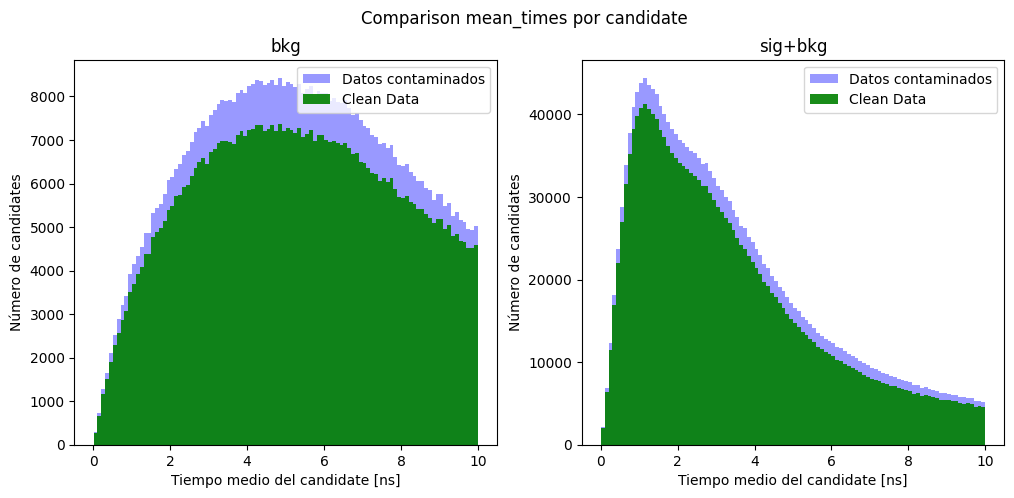

In [404]:
mean_times_by_candidate_bkg = data_by_candidate_bkg["pmt_hit_calibrated_times_corrected"].mean()
mean_times_by_candidate_sig = data_by_candidate_sig["pmt_hit_calibrated_times_corrected"].mean()


mean_times_by_candidate_bkg_clean = mean_times_by_candidate_bkg.drop(combined_series_bkg.index)
mean_times_by_candidate_sig_clean = mean_times_by_candidate_sig.drop(combined_series_sig.index)

subplot = pltext.canvas(2)

subplot(1)
plt.hist(mean_times_by_candidate_bkg, 100, color="b", label="Datos contaminados", alpha=0.4)
plt.hist(mean_times_by_candidate_bkg_clean, bins=100, color="g",label="Clean Data", alpha=0.9)
plt.xlabel("Tiempo medio del candidate [ns]")
plt.ylabel("Número de candidates")
plt.title("bkg")
plt.legend()

subplot(2)
plt.hist(mean_times_by_candidate_sig, 100, color="b", label="Datos contaminados",alpha=0.4)
plt.hist(mean_times_by_candidate_sig_clean, bins=100, color="g",label="Clean Data", alpha=0.9)
plt.xlabel("Tiempo medio del candidate [ns]")
plt.ylabel("Número de candidates")
plt.title("sig+bkg")
plt.legend()

plt.suptitle("Comparison mean_times por candidate")

## Aplicamos las masks

In [405]:
#hacemos lo mismo pero SÓLO para los candidates que pasan el cut de mask_5 y mask_10

candidates_bkg_mask_5 = total_nhits_by_candidate_bkg_clean[mask_5_bkg].index    #candidates que pasan el cut, los seleccionamos con el ínidce
candidates_bkg_mask_10 = total_nhits_by_candidate_bkg_clean[mask_10_bkg].index
candidates_sig_mask_5 = total_nhits_by_candidate_sig_clean[mask_5_sig].index
candidates_sig_mask_10 = total_nhits_by_candidate_sig_clean[mask_10_sig].index


data_bkg_mask_5 = data_bkg[data_bkg["candidate_id"].isin(candidates_bkg_mask_5)]    # .isin() devuelve una serie de valores True/False 
data_bkg_mask_10 = data_bkg[data_bkg["candidate_id"].isin(candidates_bkg_mask_10)]  #data_bkg[ lista de isin] es la serie en la que las filas es el resultado True
data_sig_mask_5 = data_sig[data_sig["candidate_id"].isin(candidates_sig_mask_5)]
data_sig_mask_10 = data_sig[data_sig["candidate_id"].isin(candidates_sig_mask_10)]

data_bkg_by_candidate_mask_5 = data_bkg_mask_5.groupby("candidate_id")  #agrupo de nuevo los hits en sus candidates
data_bkg_by_candidate_mask_10 = data_bkg_mask_10.groupby("candidate_id")
data_sig_by_candidate_mask_5 = data_sig_mask_5.groupby("candidate_id")
data_sig_by_candidate_mask_10 = data_sig_mask_10.groupby("candidate_id")


mean_times_by_candidate_bkg_mask_5 = data_bkg_by_candidate_mask_5["pmt_hit_calibrated_times_corrected"].mean()
mean_times_by_candidate_bkg_mask_10 = data_bkg_by_candidate_mask_10["pmt_hit_calibrated_times_corrected"].mean()
mean_times_by_candidate_sig_mask_5 = data_sig_by_candidate_mask_5["pmt_hit_calibrated_times_corrected"].mean()
mean_times_by_candidate_sig_mask_10 = data_sig_by_candidate_mask_10["pmt_hit_calibrated_times_corrected"].mean()


Text(0.5, 0.98, 'Comparison mean_times por candidate con cuts en nhits')

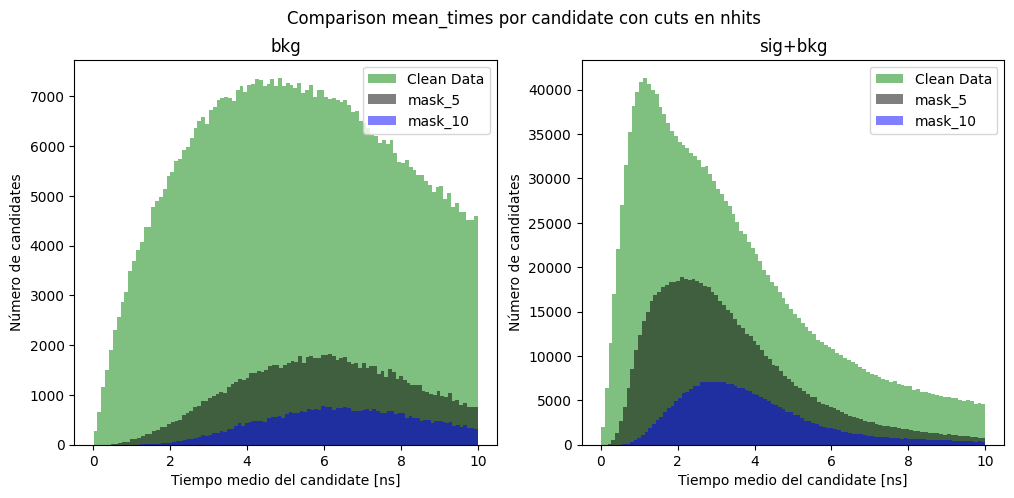

In [406]:
subplot = pltext.canvas(2)

subplot(1)
plt.hist(mean_times_by_candidate_bkg_clean, bins=100, color="g",label="Clean Data", alpha=0.5)
plt.hist(mean_times_by_candidate_bkg_mask_5, bins=100, alpha=0.5, label="mask_5")
plt.hist(mean_times_by_candidate_bkg_mask_10, bins=100, alpha=0.5, label="mask_10")
plt.xlabel("Tiempo medio del candidate [ns]")
plt.ylabel("Número de candidates")
plt.legend()
plt.title("bkg")

subplot(2)
plt.hist(mean_times_by_candidate_sig_clean, bins=100, color="g",label="Clean Data", alpha=0.5)
plt.hist(mean_times_by_candidate_sig_mask_5, bins=100, alpha=0.5, label="mask_5")
plt.hist(mean_times_by_candidate_sig_mask_10, bins=100, alpha=0.5, label="mask_10")
plt.xlabel("Tiempo medio del candidate [ns]")
plt.ylabel("Número de candidates")
plt.legend()
plt.title("sig+bkg")
plt.suptitle("Comparison mean_times por candidate con cuts en nhits")

In [407]:
#hacemos lo mismo pero SÓLO para los candidates que pasan el cut de mask_charge

candidates_bkg_mask_charge = total_nhits_by_candidate_bkg_clean[mask_charge_bkg].index    #candidates que pasan el cut, los seleccionamos con el ínidce
candidates_sig_mask_charge = total_nhits_by_candidate_sig_clean[mask_charge_sig].index

data_bkg_mask_charge = data_bkg[data_bkg["candidate_id"].isin(candidates_bkg_mask_charge)]    # .isin() devuelve una serie de valores True/False 
data_sig_mask_charge = data_sig[data_sig["candidate_id"].isin(candidates_sig_mask_charge)]

data_bkg_by_candidate_mask_charge = data_bkg_mask_charge.groupby("candidate_id")  #agrupo de nuevo los hits en sus candidates
data_sig_by_candidate_mask_charge = data_sig_mask_charge.groupby("candidate_id")

mean_times_by_candidate_bkg_mask_charge = data_bkg_by_candidate_mask_charge["pmt_hit_calibrated_times_corrected"].mean()
mean_times_by_candidate_sig_mask_charge = data_sig_by_candidate_mask_charge["pmt_hit_calibrated_times_corrected"].mean()

Text(0.5, 0.98, 'Comparison mean_times por candidate con cuts en charge')

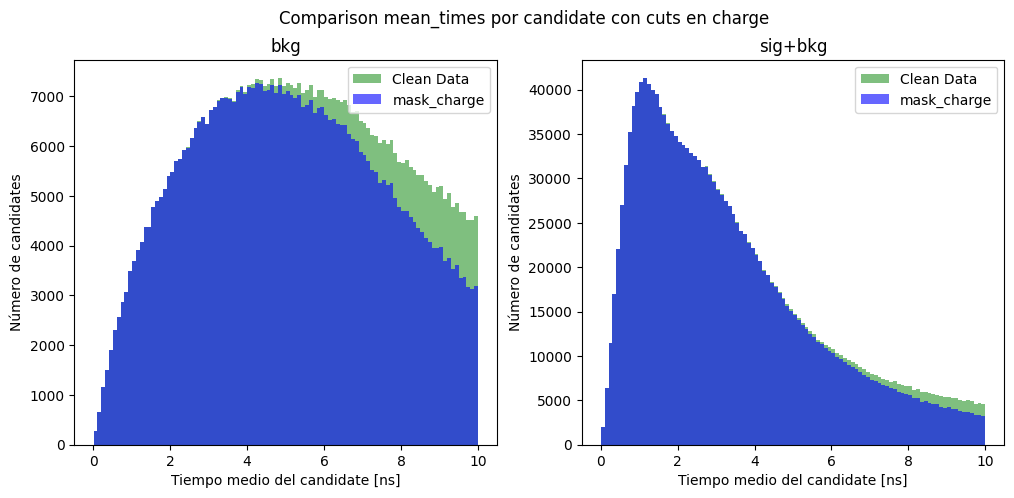

In [408]:
subplot = pltext.canvas(2)

subplot(1)
plt.hist(mean_times_by_candidate_bkg_clean, bins=100, color="g",label="Clean Data", alpha=0.5)
plt.hist(mean_times_by_candidate_bkg_mask_charge, bins=100, alpha=0.6, label="mask_charge", color="b")
plt.xlabel("Tiempo medio del candidate [ns]")
plt.ylabel("Número de candidates")
plt.legend()
plt.title("bkg")

subplot(2)
plt.hist(mean_times_by_candidate_sig_clean, bins=100, color="g",label="Clean Data", alpha=0.5)
plt.hist(mean_times_by_candidate_sig_mask_charge, bins=100, alpha=0.6, label="mask_charge", color="b")
plt.xlabel("Tiempo medio del candidate [ns]")
plt.ylabel("Número de candidates")
plt.legend()
plt.title("sig+bkg")
plt.suptitle("Comparison mean_times por candidate con cuts en charge")

In [409]:
#hacemos lo mismo pero SÓLO para los candidateos que pasan el cut de mask_trms

candidates_bkg_mask_trms = total_nhits_by_candidate_bkg_clean[mask_trms_bkg].index    #candidates que pasan el cut, los seleccionamos con el ínidce
candidates_sig_mask_trms = total_nhits_by_candidate_sig_clean[mask_trms_sig].index

data_bkg_mask_trms = data_bkg[data_bkg["candidate_id"].isin(candidates_bkg_mask_trms)]    # .isin() devuelve una serie de valores True/False 
data_sig_mask_trms = data_sig[data_sig["candidate_id"].isin(candidates_sig_mask_trms)]

data_bkg_by_candidate_mask_trms = data_bkg_mask_trms.groupby("candidate_id")  #agrupo de nuevo los hits en sus candidateos
data_sig_by_candidate_mask_trms = data_sig_mask_trms.groupby("candidate_id")

mean_times_by_candidate_bkg_mask_trms = data_bkg_by_candidate_mask_trms["pmt_hit_calibrated_times_corrected"].mean()
mean_times_by_candidate_sig_mask_trms = data_sig_by_candidate_mask_trms["pmt_hit_calibrated_times_corrected"].mean()

Text(0.5, 0.98, 'Comparison mean_times por candidate con cuts en tRMS')

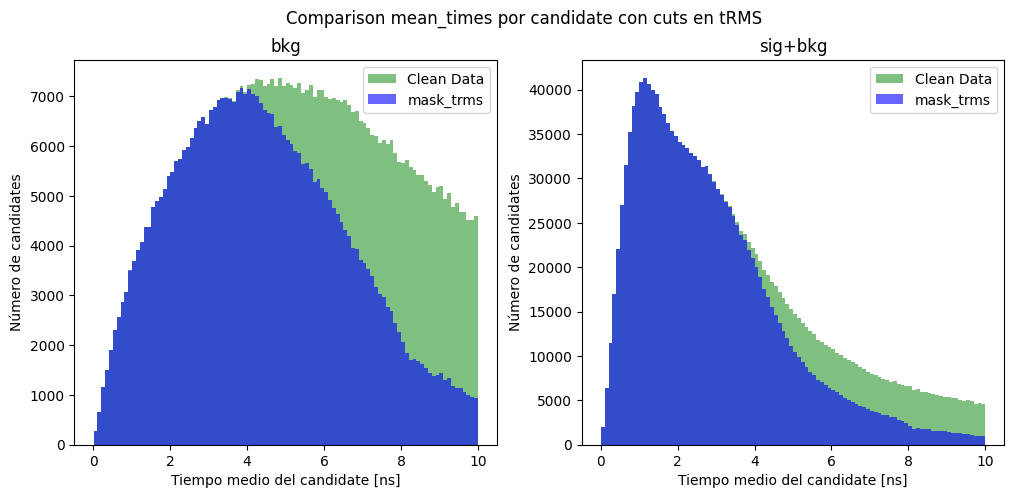

In [410]:
subplot = pltext.canvas(2)

subplot(1)
plt.hist(mean_times_by_candidate_bkg_clean, bins=100, color="g",label="Clean Data", alpha=0.5)
plt.hist(mean_times_by_candidate_bkg_mask_trms, bins=100, alpha=0.6, label="mask_trms", color="b")
plt.xlabel("Tiempo medio del candidate [ns]")
plt.ylabel("Número de candidates")
plt.legend()
plt.title("bkg")

subplot(2)
plt.hist(mean_times_by_candidate_sig_clean, bins=100, color="g",label="Clean Data", alpha=0.5)
plt.hist(mean_times_by_candidate_sig_mask_trms, bins=100, alpha=0.6, label="mask_trms", color="b")
plt.xlabel("Tiempo medio del candidate [ns]")
plt.ylabel("Número de candidates")
plt.legend()
plt.title("sig+bkg")
plt.suptitle("Comparison mean_times por candidate con cuts en tRMS")

## Recap distrib no. eventos y tiempo medio con masks

Text(0.5, 1.0, 'sig+bkg')

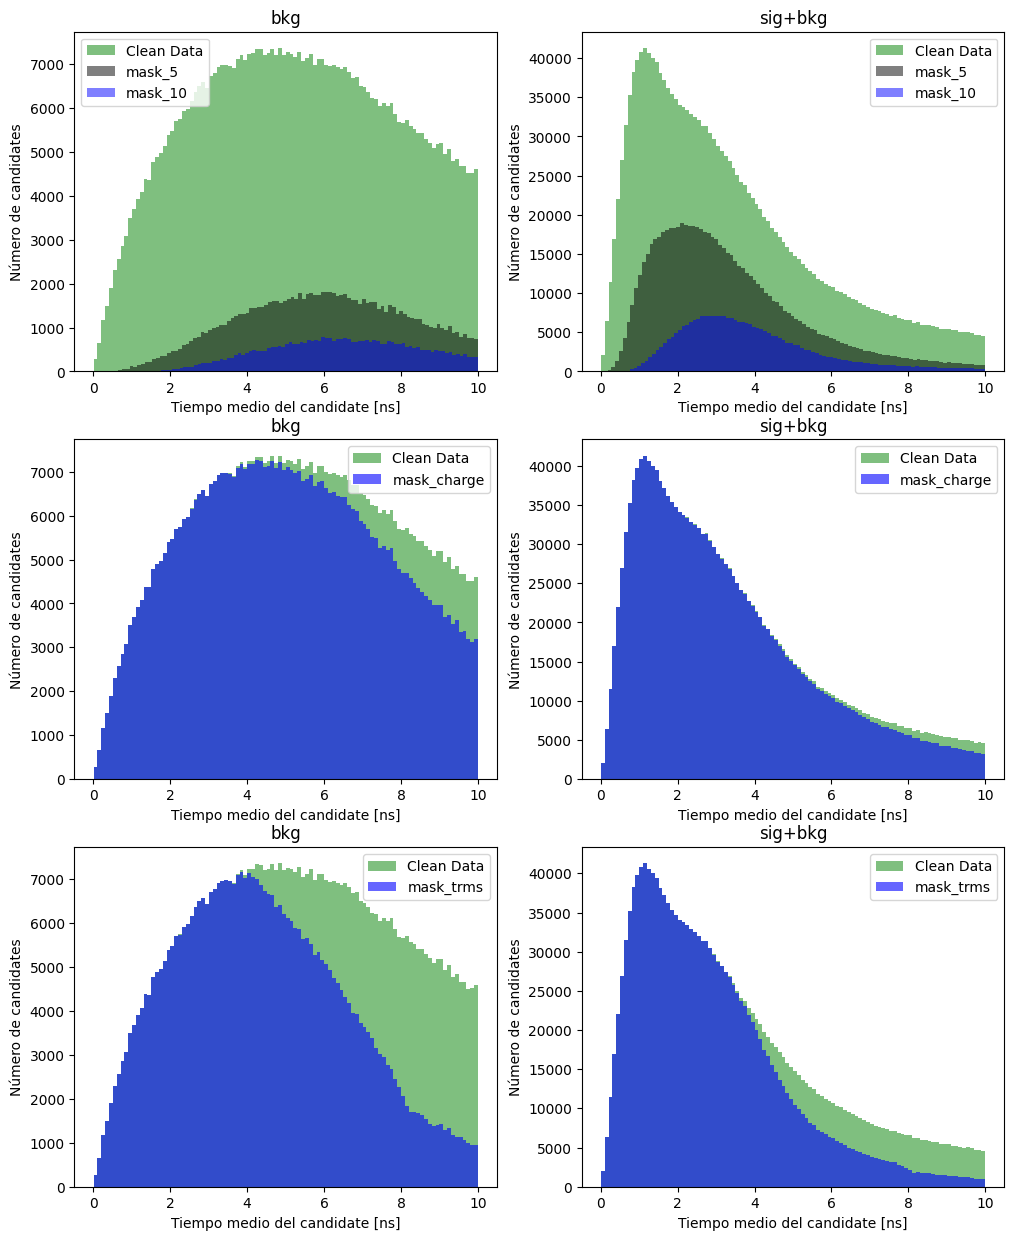

In [411]:
subplot = pltext.canvas(6)

subplot(1)
plt.hist(mean_times_by_candidate_bkg_clean, bins=100, color="g",label="Clean Data", alpha=0.5)
plt.hist(mean_times_by_candidate_bkg_mask_5, bins=100, alpha=0.5, label="mask_5")
plt.hist(mean_times_by_candidate_bkg_mask_10, bins=100, alpha=0.5, label="mask_10")
plt.xlabel("Tiempo medio del candidate [ns]")
plt.ylabel("Número de candidates")
plt.legend()
plt.title("bkg")

subplot(2)
plt.hist(mean_times_by_candidate_sig_clean, bins=100, color="g",label="Clean Data", alpha=0.5)
plt.hist(mean_times_by_candidate_sig_mask_5, bins=100, alpha=0.5, label="mask_5")
plt.hist(mean_times_by_candidate_sig_mask_10, bins=100, alpha=0.5, label="mask_10")
plt.xlabel("Tiempo medio del candidate [ns]")
plt.ylabel("Número de candidates")
plt.legend()
plt.title("sig+bkg")

subplot(3)
plt.hist(mean_times_by_candidate_bkg_clean, bins=100, color="g",label="Clean Data", alpha=0.5)
plt.hist(mean_times_by_candidate_bkg_mask_charge, bins=100, alpha=0.6, label="mask_charge", color="b")
plt.xlabel("Tiempo medio del candidate [ns]")
plt.ylabel("Número de candidates")
plt.legend()
plt.title("bkg")

subplot(4)
plt.hist(mean_times_by_candidate_sig_clean, bins=100, color="g",label="Clean Data", alpha=0.5)
plt.hist(mean_times_by_candidate_sig_mask_charge, bins=100, alpha=0.6, label="mask_charge", color="b")
plt.xlabel("Tiempo medio del candidate [ns]")
plt.ylabel("Número de candidates")
plt.legend()
plt.title("sig+bkg")

subplot(5)
plt.hist(mean_times_by_candidate_bkg_clean, bins=100, color="g",label="Clean Data", alpha=0.5)
plt.hist(mean_times_by_candidate_bkg_mask_trms, bins=100, alpha=0.6, label="mask_trms", color="b")
plt.xlabel("Tiempo medio del candidate [ns]")
plt.ylabel("Número de candidates")
plt.legend()
plt.title("bkg")

subplot(6)
plt.hist(mean_times_by_candidate_sig_clean, bins=100, color="g",label="Clean Data", alpha=0.5)
plt.hist(mean_times_by_candidate_sig_mask_trms, bins=100, alpha=0.6, label="mask_trms", color="b")
plt.xlabel("Tiempo medio del candidate [ns]")
plt.ylabel("Número de candidates")
plt.legend()
plt.title("sig+bkg")